# TalentPulse Salary Prediction
## End-to-End Regression Pipeline

**Role:** Machine Learning Engineer  
**Primary objective:** build an explainable salary-regression pipeline and determine whether it improves on the legacy **$18,500 MAE**.  
**Source:** TalentPulse Jobs Dataset, 4,653 job postings across five countries.

This notebook is self-contained and executes from raw data through cleaning, EDA, feature engineering, model comparison, tuning, final evaluation, scoring, charts, and the HR benchmarking memo.

## tl;dr

The validated run produces **2,229 model-ready labeled records**, **2,336 unlabeled scoring records**, and a **66-row review queue**. Random Forest is the strongest untuned development model. The selected tuned model uses engineered features, job-title text, and a log target.

Final locked-holdout performance is approximately:

- **MAE:** $20,175
- **RMSE:** $30,194
- **R2:** 0.694

The model does **not** beat the legacy $18,500 MAE, so it should not replace the legacy system yet. The main blockers are missing pay-period metadata and weak labeled coverage in Australia, Canada, and India.

## Context & Methods

The case study requires:

1. full data validation, cleaning, and EDA;
2. defensible handling of missing salary targets;
3. currency standardization and salary-unit review;
4. salary-range, seniority, experience, and skill engineering;
5. Pearson correlation, VIF, and log-target analysis;
6. Linear Regression, Random Forest, and Gradient Boosting comparison;
7. five-fold cross-validation and tuning;
8. Random Forest depth and Ridge-alpha diagnostics;
9. Standard-versus-Premium and subgroup bias evaluation;
10. an actionable HR salary-benchmarking recommendation.

### Key assumptions

- Missing `salary_avg` values are never imputed. They form the scoring pool.
- Salary values are treated as local currency and converted using fixed 2024 rates.
- The dataset has no pay-period field. Questionable values are quarantined rather than silently annualized.
- Review floors are $20,000 for USA, UK, Canada, and Australia; $3,000 for India. The upper review threshold is $500,000.
- Salary bounds and salary range are target-derived and excluded from model inputs.
- Model selection uses development cross-validation. The final holdout is opened only after selection and tuning.

## Setup

Import dependencies, define constants, and configure deterministic behavior.

In [1]:
from __future__ import annotations

import argparse

import ast

import hashlib

import json

import warnings

from dataclasses import dataclass

from pathlib import Path

from typing import Any

import joblib

import matplotlib

matplotlib.use("Agg")

import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import seaborn as sns

from scipy import stats

from sklearn.base import clone

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.inspection import permutation_importance

from statsmodels.stats.outliers_influence import variance_inflation_factor

from IPython.display import Image, Markdown, display

In [2]:
RANDOM_STATE = 42

TEST_SIZE = 0.20

CV_FOLDS = 5

LEGACY_MAE_USD = 18_500.0

INDUSTRY_MAE_USD = 8_000.0

MAX_ANNUAL_SALARY_USD = 500_000.0

MIN_ANNUAL_SALARY_USD = {
    "USA": 20_000.0,
    "UK": 20_000.0,
    "Canada": 20_000.0,
    "Australia": 20_000.0,
    "India": 3_000.0,
}

COUNTRY_CURRENCY = {
    "USA": {"currency": "USD", "lcu_per_usd": 1.00},
    "UK": {"currency": "GBP", "lcu_per_usd": 0.78},
    "Canada": {"currency": "CAD", "lcu_per_usd": 1.37},
    "India": {"currency": "INR", "lcu_per_usd": 83.67},
    "Australia": {"currency": "AUD", "lcu_per_usd": 1.52},
}

EXPECTED_COLUMNS = [
    "job_id",
    "job_title",
    "company",
    "location",
    "salary_min",
    "salary_max",
    "description",
    "country",
    "search_keyword",
    "experience_required",
    "degree_required",
    "skills",
    "num_skills",
    "job_level",
    "is_remote",
    "salary_avg",
    "has_salary",
]

EXPECTED_COUNTRIES = set(COUNTRY_CURRENCY)

EXPECTED_LEVELS = {"Junior", "Mid", "Senior", "Lead"}

ALL_SKILLS = [
    "python",
    "sql",
    "spark",
    "aws",
    "excel",
    "machine learning",
    "power bi",
    "tableau",
]

TOP_SKILLS = ["python", "sql", "spark", "aws"]

BLUE = "#2563EB"

GOLD = "#D97706"

PINK = "#DB2777"

OLIVE = "#657A2E"

PURPLE = "#7C3AED"

CHARCOAL = "#273444"

MID_GREY = "#64748B"

LIGHT_GREY = "#E5E7EB"

COUNTRY_PALETTE = {
    "USA": BLUE,
    "UK": GOLD,
    "Canada": PINK,
    "India": OLIVE,
    "Australia": PURPLE,
}

LEVEL_ORDER = ["Junior", "Mid", "Senior", "Lead"]

@dataclass(frozen=True)
class FeatureSpec:
    """Columns and preprocessing branches used by one feature-set candidate."""

    categorical: tuple[str, ...]
    numeric: tuple[str, ...] = ()
    text: str | None = None

    @property
    def columns(self) -> list[str]:
        ordered = [*self.categorical, *self.numeric]
        if self.text:
            ordered.append(self.text)
        return list(dict.fromkeys(ordered))

CORE_CATEGORICAL = (
    "country",
    "job_level",
    "is_remote",
    "search_keyword",
    "degree_required",
)

TOP_SKILL_COLUMNS = tuple(f"skill_{skill.replace(' ', '_')}" for skill in TOP_SKILLS)

FEATURE_SPECS = {
    "Core": FeatureSpec(categorical=CORE_CATEGORICAL),
    "Core + num_skills": FeatureSpec(
        categorical=CORE_CATEGORICAL,
        numeric=("num_skills", "skills_extracted"),
    ),
    "Core + top skills": FeatureSpec(
        categorical=CORE_CATEGORICAL,
        numeric=("skills_extracted", *TOP_SKILL_COLUMNS),
    ),
    "Core + nonredundant engineered": FeatureSpec(
        categorical=(*CORE_CATEGORICAL, "experience_tier"),
        numeric=(
            "experience_required_clean",
            "experience_missing",
            "skills_extracted",
            *TOP_SKILL_COLUMNS,
        ),
    ),
    "Engineered + job-title text": FeatureSpec(
        categorical=(*CORE_CATEGORICAL, "experience_tier"),
        numeric=(
            "experience_required_clean",
            "experience_missing",
            "skills_extracted",
            *TOP_SKILL_COLUMNS,
        ),
        text="job_title_text",
    ),
}

### Concision notes

The code uses short forms where they give identical results:

- `df.copy()` is already a deep copy by default.
- `100 * df.isna().mean()` is equivalent to `df.isna().sum() / len(df) * 100`.
- `series.gt(0)` already returns `False` for missing values.

### Utility and data-quality functions

In [3]:
def configure_output(output_root: Path) -> dict[str, Path]:
    paths = {
        "processed": output_root / "data" / "processed",
        "figures": output_root / "reports" / "figures",
        "reports": output_root / "reports",
        "models": output_root / "models",
    }
    for path in paths.values():
        path.mkdir(parents=True, exist_ok=True)
    return paths


def normalize_text(series: pd.Series) -> pd.Series:
    return (
        series.fillna("")
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


def normalized_key(series: pd.Series) -> pd.Series:
    return normalize_text(series).str.lower()


def parse_skills(value: Any) -> list[str]:
    if isinstance(value, (list, tuple, set)):
        items = value
    elif pd.isna(value):
        return []
    else:
        try:
            items = ast.literal_eval(str(value))
        except (ValueError, SyntaxError):
            return []
    if not isinstance(items, (list, tuple, set)):
        return []
    return sorted({normalized for item in items if (normalized := str(item).strip().lower())})


def add_duplicate_audit(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    key_columns = ["job_title", "company", "location", "country", "description"]
    fingerprint_text = pd.DataFrame(
        {column: normalized_key(result[column]) for column in key_columns}
    ).agg("|".join, axis=1)
    result["posting_fingerprint"] = fingerprint_text.map(
        lambda value: hashlib.sha1(value.encode("utf-8")).hexdigest()
    )
    groups = result.groupby("posting_fingerprint", dropna=False)
    result["duplicate_group_size"] = groups["job_id"].transform("size")
    result["duplicate_salary_conflict"] = groups["salary_avg"].transform("nunique") > 1
    result["duplicate_level_conflict"] = groups["job_level"].transform("nunique") > 1
    result["duplicate_remote_conflict"] = groups["is_remote"].transform("nunique") > 1
    result["duplicate_conflict"] = result[
        [
            "duplicate_salary_conflict",
            "duplicate_level_conflict",
            "duplicate_remote_conflict",
        ]
    ].any(axis=1)

    positive_bounds = result[["salary_min", "salary_max"]].gt(0).all(axis=1)
    result["_canonical_priority"] = (
        result["salary_avg"].notna().astype(int) * 2 + positive_bounds.astype(int)
    )
    eligible = result.loc[~result["duplicate_conflict"]]
    canonical_indices = (
        eligible.sort_values(
            ["posting_fingerprint", "_canonical_priority", "job_id"],
            ascending=[True, False, True],
        )
        .groupby("posting_fingerprint", sort=False)
        .head(1)
        .index
    )
    result["duplicate_action"] = "drop_duplicate"
    result.loc[canonical_indices, "duplicate_action"] = "keep"
    result.loc[result["duplicate_conflict"], "duplicate_action"] = "conflict_review"
    return result.drop(columns="_canonical_priority")


def clean_and_engineer(raw: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    missing_columns = sorted(set(EXPECTED_COLUMNS) - set(raw.columns))
    if missing_columns:
        raise ValueError(f"Required columns are missing: {missing_columns}")
    if raw["job_id"].isna().any() or not raw["job_id"].is_unique:
        raise ValueError("job_id must be complete and unique at source grain.")
    if set(raw["country"].dropna()) != EXPECTED_COUNTRIES:
        raise ValueError("country values differ from the five-country data contract.")
    if set(raw["job_level"].dropna()) != EXPECTED_LEVELS:
        raise ValueError("job_level values differ from the four-level data contract.")

    silver = raw.copy()
    text_columns = silver.select_dtypes(include=["object", "string"]).columns
    for column in text_columns:
        silver[column] = normalize_text(silver[column]).replace("", pd.NA)

    silver = add_duplicate_audit(silver)

    currency_map = {key: value["currency"] for key, value in COUNTRY_CURRENCY.items()}
    rate_map = {key: value["lcu_per_usd"] for key, value in COUNTRY_CURRENCY.items()}
    silver["currency"] = silver["country"].map(currency_map)
    silver["lcu_per_usd"] = silver["country"].map(rate_map)
    if silver["lcu_per_usd"].isna().any():
        raise ValueError("At least one country has no currency conversion rate.")

    for column in ["salary_min", "salary_avg", "salary_max"]:
        silver[column] = pd.to_numeric(silver[column], errors="coerce")
        silver[f"{column}_local"] = silver[column]
        silver[f"{column}_usd"] = silver[column] / silver["lcu_per_usd"]

    has_target = silver["salary_avg_usd"].gt(0)
    complete_bounds = silver[["salary_min", "salary_max"]].notna().all(axis=1)
    positive_bounds = silver[["salary_min", "salary_max"]].gt(0).all(axis=1)
    ordered_bounds = silver["salary_min"].le(silver["salary_avg"]) & silver[
        "salary_avg"
    ].le(silver["salary_max"])
    silver["salary_invalid_bounds"] = has_target & ~(
        complete_bounds & positive_bounds & ordered_bounds
    )
    silver["salary_midpoint_usd"] = (
        silver["salary_min_usd"] + silver["salary_max_usd"]
    ) / 2
    silver["salary_midpoint_mismatch"] = (
        has_target
        & complete_bounds
        & ~np.isclose(
            silver["salary_avg_usd"],
            silver["salary_midpoint_usd"],
            rtol=1e-7,
            atol=0.01,
            equal_nan=True,
        )
    )
    silver["salary_range_local"] = silver["salary_max"] - silver["salary_min"]
    silver["salary_range_usd"] = silver["salary_max_usd"] - silver["salary_min_usd"]
    country_floor = silver["country"].map(MIN_ANNUAL_SALARY_USD)
    silver["salary_unit_review"] = (
        has_target
        & ~silver["salary_invalid_bounds"]
        & (
            silver["salary_avg_usd"].lt(country_floor)
            | silver["salary_avg_usd"].gt(MAX_ANNUAL_SALARY_USD)
        )
    )

    canonical = silver["duplicate_action"].eq("keep")
    model_ready = (
        canonical
        & has_target
        & ~silver["salary_invalid_bounds"]
        & ~silver["salary_unit_review"]
        & ~silver["salary_midpoint_mismatch"]
    )
    unlabeled = canonical & silver["salary_avg"].isna()
    silver["salary_quality_status"] = np.select(
        [
            silver["duplicate_action"].eq("conflict_review"),
            silver["duplicate_action"].eq("drop_duplicate"),
            model_ready,
            unlabeled,
            silver["salary_invalid_bounds"],
            silver["salary_unit_review"],
            silver["salary_midpoint_mismatch"],
        ],
        [
            "duplicate_conflict",
            "duplicate_removed",
            "model_ready",
            "unlabeled",
            "invalid_bounds",
            "unit_review",
            "midpoint_mismatch",
        ],
        default="review_other",
    )

    experience = pd.to_numeric(silver["experience_required"], errors="coerce")
    silver["experience_invalid"] = experience.notna() & ~experience.between(0, 30)
    silver["experience_required_clean"] = experience.where(experience.between(0, 30))
    silver["experience_missing"] = silver["experience_required_clean"].isna().astype("int8")
    silver["experience_tier"] = pd.cut(
        silver["experience_required_clean"],
        bins=[-0.01, 2, 5, 10, 30],
        labels=["Entry", "Intermediate", "Experienced", "Highly Experienced"],
    )

    silver["is_senior"] = silver["job_level"].isin(["Senior", "Lead"]).astype("int8")
    silver["salary_segment"] = silver["is_senior"].map(
        {0: "Standard", 1: "Premium"}
    )
    silver["skills_list"] = silver["skills"].map(parse_skills)
    silver["skills_extracted"] = silver["skills_list"].str.len().gt(0).astype("int8")
    for skill in ALL_SKILLS:
        column = f"skill_{skill.replace(' ', '_')}"
        silver[column] = silver["skills_list"].map(lambda values, s=skill: int(s in values))
    skill_columns = [f"skill_{skill.replace(' ', '_')}" for skill in ALL_SKILLS]
    silver["parsed_skill_count"] = silver[skill_columns].sum(axis=1)
    silver["num_skills_mismatch"] = silver["num_skills"].ne(silver["parsed_skill_count"])
    silver["job_title_text"] = normalized_key(silver["job_title"])
    silver["log_salary_avg_usd"] = np.log1p(silver["salary_avg_usd"])

    quality_profile = pd.DataFrame(
        {
            "dtype": raw.dtypes.astype(str),
            "missing_count": raw.isna().sum(),
            # Shorter equivalent to missing_count / len(raw) * 100.
            "missing_pct": (100 * raw.isna().mean()).round(2),
            "distinct_count": raw.nunique(dropna=False),
        }
    ).sort_values(["missing_pct", "distinct_count"], ascending=[False, False])
    return silver, quality_profile

### Modeling and metric functions

In [4]:
def make_preprocessor(spec: FeatureSpec) -> ColumnTransformer:
    transformers: list[tuple[str, Any, Any]] = []
    if spec.categorical:
        categorical = Pipeline(
            [
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        drop="first",
                        min_frequency=3,
                        sparse_output=False,
                    ),
                ),
            ]
        )
        transformers.append(("categorical", categorical, list(spec.categorical)))
    if spec.numeric:
        numerical = Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                ("scaler", StandardScaler()),
            ]
        )
        transformers.append(("numeric", numerical, list(spec.numeric)))
    if spec.text:
        title_vectorizer = TfidfVectorizer(
            lowercase=False,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=3,
            max_features=400,
            sublinear_tf=True,
        )
        transformers.append(("title", title_vectorizer, spec.text))
    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        sparse_threshold=0.0,
        verbose_feature_names_out=False,
    )


def make_model_pipeline(spec: FeatureSpec, model: Any) -> Pipeline:
    return Pipeline([("preprocess", make_preprocessor(spec)), ("model", model)])


def metric_values(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(mean_squared_error(y_true, y_pred) ** 0.5),
        "R2": float(r2_score(y_true, y_pred)),
    }


def cv_summary(estimator: Any, X: pd.DataFrame, y: pd.Series, cv: list[tuple]) -> dict:
    scores = cross_validate(
        estimator,
        X,
        y,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2",
        },
        return_train_score=True,
        n_jobs=-1,
    )
    return {
        "CV_MAE": float(-scores["test_MAE"].mean()),
        "CV_MAE_SD": float(scores["test_MAE"].std()),
        "CV_RMSE": float(-scores["test_RMSE"].mean()),
        "CV_R2": float(scores["test_R2"].mean()),
        "Train_MAE": float(-scores["train_MAE"].mean()),
    }

### Chart and EDA functions

In [5]:
def save_figure(fig: plt.Figure, path: Path) -> None:
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight", facecolor="white")
    plt.close(fig)


def add_title(ax: plt.Axes, title: str, subtitle: str) -> None:
    ax.set_title(title, loc="left", weight="bold", pad=30, color=CHARCOAL)
    ax.text(
        0,
        1.02,
        subtitle,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=9,
        color=MID_GREY,
    )


def create_eda_outputs(
    silver: pd.DataFrame,
    training: pd.DataFrame,
    quality_profile: pd.DataFrame,
    figures_dir: Path,
    processed_dir: Path,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    missing = quality_profile.query("missing_count > 0").sort_values("missing_pct")
    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.barh(missing.index, missing["missing_pct"], color=BLUE, edgecolor=CHARCOAL)
    add_title(ax, "Missing Data by Column", f"Source rows: {len(silver):,}; percentages use source grain")
    ax.set_xlabel("Missing values (%)")
    ax.set_ylabel("")
    ax.set_xlim(left=0)
    sns.despine(ax=ax)
    save_figure(fig, figures_dir / "01_missing_data_by_column.png")

    coverage = (
        silver.loc[silver["duplicate_action"].eq("keep")]
        .groupby("country")
        .agg(
            total_postings=("job_id", "size"),
            model_ready=("salary_quality_status", lambda s: s.eq("model_ready").sum()),
            unlabeled=("salary_quality_status", lambda s: s.eq("unlabeled").sum()),
        )
        .assign(coverage_pct=lambda d: 100 * d["model_ready"] / d["total_postings"])
        .reset_index()
        .sort_values("coverage_pct", ascending=False)
    )
    coverage.to_csv(processed_dir / "salary_coverage_by_country.csv", index=False)
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=coverage, x="country", y="coverage_pct", color=BLUE, ax=ax)
    for patch, value in zip(ax.patches, coverage["coverage_pct"]):
        ax.text(patch.get_x() + patch.get_width() / 2, value + 1, f"{value:.1f}%", ha="center")
    add_title(ax, "Model-Ready Salary Coverage by Country", "Canonical postings after duplicate and salary-quality review")
    ax.set_xlabel("")
    ax.set_ylabel("Model-ready postings (%)")
    ax.set_ylim(0, 108)
    sns.despine(ax=ax)
    save_figure(fig, figures_dir / "02_salary_coverage_by_country.png")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.histplot(training["salary_avg_usd"], bins=35, color=BLUE, edgecolor="white", ax=axes[0])
    axes[0].axvline(training["salary_avg_usd"].median(), color=GOLD, linestyle="--", label="Median")
    axes[0].set_title("Annual Salary Distribution", loc="left", weight="bold")
    axes[0].set_xlabel("Average salary (2024 USD)")
    axes[0].set_ylabel("Postings")
    axes[0].legend(frameon=False)
    sns.histplot(training["log_salary_avg_usd"], bins=35, color=GOLD, edgecolor="white", ax=axes[1])
    axes[1].set_title("Log-Transformed Salary Distribution", loc="left", weight="bold")
    axes[1].set_xlabel("log1p(average salary in 2024 USD)")
    axes[1].set_ylabel("Postings")
    fig.suptitle(f"Model-ready labeled records (n={len(training):,})", x=0.01, ha="left", color=MID_GREY)
    for ax in axes:
        sns.despine(ax=ax)
    save_figure(fig, figures_dir / "03_salary_distribution_and_log.png")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
    stats.probplot(training["salary_avg_usd"], dist="norm", plot=axes[0])
    stats.probplot(training["log_salary_avg_usd"], dist="norm", plot=axes[1])
    axes[0].set_title("Q-Q Plot: Salary in USD", loc="left", weight="bold")
    axes[1].set_title("Q-Q Plot: Log Salary", loc="left", weight="bold")
    for ax in axes:
        ax.get_lines()[0].set_markerfacecolor(BLUE)
        ax.get_lines()[0].set_markeredgecolor(BLUE)
        ax.get_lines()[0].set_alpha(0.45)
        ax.get_lines()[1].set_color(CHARCOAL)
        ax.grid(color=LIGHT_GREY, linewidth=0.8)
    fig.suptitle("Normality comparison for the model-ready target", x=0.01, ha="left", color=MID_GREY)
    save_figure(fig, figures_dir / "04_salary_qq_before_after_log.png")

    correlation_features = [
        "num_skills",
        "experience_required_clean",
        "is_remote",
        "is_senior",
        "skills_extracted",
        *TOP_SKILL_COLUMNS,
    ]
    rows = []
    for feature in correlation_features:
        pair = training[["salary_avg_usd", feature]].dropna()
        rows.append(
            {
                "feature": feature,
                "pearson_r": pair["salary_avg_usd"].corr(pair[feature]),
                "pair_count": len(pair),
            }
        )
    correlations = pd.DataFrame(rows).sort_values(
        "pearson_r", key=lambda values: values.abs(), ascending=False
    )
    correlations.to_csv(processed_dir / "numeric_target_correlations.csv", index=False)
    chart = correlations.sort_values("pearson_r")
    fig, ax = plt.subplots(figsize=(9, 5.8))
    colors = [GOLD if value < 0 else BLUE for value in chart["pearson_r"]]
    ax.barh(chart["feature"], chart["pearson_r"], color=colors, edgecolor=CHARCOAL)
    ax.axvline(0, color=CHARCOAL, linewidth=1)
    add_title(ax, "Pearson Correlation with Average Salary", "2024 USD; pairwise complete observations; leakage fields excluded")
    ax.set_xlabel("Pearson r")
    ax.set_ylabel("")
    sns.despine(ax=ax)
    save_figure(fig, figures_dir / "05_numeric_feature_correlations.png")

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(
        data=training,
        x="country",
        y="salary_avg_usd",
        hue="job_level",
        hue_order=LEVEL_ORDER,
        palette={"Junior": "#93C5FD", "Mid": BLUE, "Senior": GOLD, "Lead": PINK},
        showfliers=False,
        ax=ax,
    )
    add_title(ax, "Average Salary by Country and Job Level", f"Model-ready postings (n={len(training):,}); outlier markers hidden")
    ax.set_xlabel("")
    ax.set_ylabel("Average salary (2024 USD)")
    ax.set_ylim(bottom=0)
    ax.legend(title="Job level", frameon=False, ncol=4, loc="upper left")
    sns.despine(ax=ax)
    save_figure(fig, figures_dir / "06_salary_by_country_and_job_level.png")

    role_country = (
        training.groupby(["search_keyword", "country"], observed=True)
        .agg(postings=("job_id", "size"), median_salary_usd=("salary_avg_usd", "median"))
        .reset_index()
    )
    role_country.to_csv(processed_dir / "salary_by_role_family_country.csv", index=False)
    fig, ax = plt.subplots(figsize=(13, 6))
    sns.barplot(
        data=role_country,
        x="search_keyword",
        y="median_salary_usd",
        hue="country",
        palette=COUNTRY_PALETTE,
        edgecolor=CHARCOAL,
        errorbar=None,
        ax=ax,
    )
    add_title(ax, "Median Salary by Role Family and Country", "search_keyword is used instead of 1,500+ raw job-title categories")
    ax.set_xlabel("")
    ax.set_ylabel("Median average salary (2024 USD)")
    ax.tick_params(axis="x", rotation=15)
    ax.legend(title="Country", frameon=False, ncol=5, loc="upper left")
    sns.despine(ax=ax)
    save_figure(fig, figures_dir / "07_salary_by_role_family_country.png")
    return coverage, correlations


def calculate_vif(training: pd.DataFrame, processed_dir: Path, figures_dir: Path) -> pd.DataFrame:
    vif_columns = [
        "num_skills",
        "is_remote",
        "is_senior",
        "experience_missing",
        "skills_extracted",
        *[f"skill_{skill.replace(' ', '_')}" for skill in ALL_SKILLS],
    ]
    matrix = training[vif_columns].astype(float).copy()
    matrix = matrix.fillna(matrix.median())
    matrix.insert(0, "constant", 1.0)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        values = [variance_inflation_factor(matrix.values, i) for i in range(matrix.shape[1])]
    vif = pd.DataFrame({"feature": matrix.columns, "VIF": values}).query(
        "feature != 'constant'"
    )
    vif = vif.sort_values("VIF", ascending=False).reset_index(drop=True)
    vif.to_csv(processed_dir / "vif_results.csv", index=False)

    finite = vif.loc[np.isfinite(vif["VIF"]), "VIF"]
    cap = max(25.0, float(finite.max()) if not finite.empty else 25.0)
    chart = vif.assign(display_vif=vif["VIF"].replace(np.inf, cap)).sort_values("display_vif")
    fig, ax = plt.subplots(figsize=(9, 7))
    colors = [GOLD if value > 10 else BLUE for value in chart["display_vif"]]
    ax.barh(chart["feature"], chart["display_vif"], color=colors, edgecolor=CHARCOAL)
    ax.axvline(10, color=CHARCOAL, linestyle="--", label="VIF = 10")
    add_title(ax, "Variance Inflation Factors", f"Infinite values are capped at {cap:.1f} for display; exact values are in vif_results.csv")
    ax.set_xlabel("VIF")
    ax.set_ylabel("")
    ax.legend(frameon=False)
    sns.despine(ax=ax)
    save_figure(fig, figures_dir / "08_vif_results.png")
    return vif

### Model-diagnostic and tuning functions

In [6]:
def feature_set_ablation(
    development: pd.DataFrame,
    y_dev: pd.Series,
    cv_splits: list[tuple],
    processed_dir: Path,
    figures_dir: Path,
) -> tuple[str, pd.DataFrame]:
    rows = []
    for name, spec in FEATURE_SPECS.items():
        estimator = make_model_pipeline(spec, Ridge(alpha=10.0))
        summary = cv_summary(estimator, development[spec.columns], y_dev, cv_splits)
        rows.append({"Feature_Set": name, **summary})
    results = pd.DataFrame(rows).sort_values("CV_R2", ascending=False).reset_index(drop=True)
    results.to_csv(processed_dir / "feature_set_ablation.csv", index=False)
    selected_name = str(results.loc[0, "Feature_Set"])

    chart = results.sort_values("CV_R2")
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = [GOLD if name == selected_name else BLUE for name in chart["Feature_Set"]]
    ax.barh(chart["Feature_Set"], chart["CV_R2"], color=colors, edgecolor=CHARCOAL)
    add_title(ax, "Feature-Set Cross-Validated R2", "Five country-balanced development folds; Ridge provides a common comparison model")
    ax.set_xlabel("Mean validation R2")
    ax.set_ylabel("")
    sns.despine(ax=ax)
    save_figure(fig, figures_dir / "09_feature_set_ablation.png")
    return selected_name, results


def ridge_alpha_analysis(
    spec: FeatureSpec,
    development: pd.DataFrame,
    y_dev: pd.Series,
    cv_splits: list[tuple],
    processed_dir: Path,
    figures_dir: Path,
) -> tuple[float, pd.DataFrame]:
    estimator = make_model_pipeline(spec, Ridge())
    alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1_000.0]
    search = GridSearchCV(
        estimator,
        {"model__alpha": alphas},
        scoring="neg_mean_absolute_error",
        cv=cv_splits,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )
    X_dev = development[spec.columns]
    search.fit(X_dev, y_dev)
    results = pd.DataFrame(
        {
            "alpha": [params["model__alpha"] for params in search.cv_results_["params"]],
            "CV_MAE": -search.cv_results_["mean_test_score"],
            "Train_MAE": -search.cv_results_["mean_train_score"],
        }
    ).sort_values("alpha")
    results.to_csv(processed_dir / "ridge_alpha_results.csv", index=False)
    best_alpha = float(search.best_params_["model__alpha"])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.semilogx(results["alpha"], results["CV_MAE"], marker="o", color=BLUE, label="Validation MAE")
    ax.semilogx(results["alpha"], results["Train_MAE"], marker="s", linestyle="--", color=GOLD, label="Train MAE")
    ax.axvline(best_alpha, color=CHARCOAL, linestyle=":", label=f"Best alpha = {best_alpha:g}")
    add_title(ax, "Ridge Regularization Search", "Five country-balanced development folds; lower MAE is better")
    ax.set_xlabel("Ridge alpha (log scale)")
    ax.set_ylabel("MAE (USD)")
    ax.legend(frameon=False)
    sns.despine(ax=ax)
    save_figure(fig, figures_dir / "10_ridge_alpha_search.png")
    return best_alpha, results


def random_forest_depth_analysis(
    spec: FeatureSpec,
    development: pd.DataFrame,
    y_dev: pd.Series,
    processed_dir: Path,
    figures_dir: Path,
) -> tuple[str, pd.DataFrame]:
    fit_data, validation_data, y_fit, y_validation = train_test_split(
        development,
        y_dev,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=development["country"],
    )
    rows = []
    for depth in range(3, 21):
        estimator = make_model_pipeline(
            spec,
            RandomForestRegressor(
                n_estimators=250,
                max_depth=depth,
                min_samples_leaf=2,
                max_features=0.7,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        )
        estimator.fit(fit_data[spec.columns], y_fit)
        train_pred = estimator.predict(fit_data[spec.columns])
        validation_pred = estimator.predict(validation_data[spec.columns])
        train_mae = mean_absolute_error(y_fit, train_pred)
        validation_mae = mean_absolute_error(y_validation, validation_pred)
        rows.append(
            {
                "max_depth": depth,
                "Train_MAE": train_mae,
                "Validation_MAE": validation_mae,
                "MAE_Gap": validation_mae - train_mae,
            }
        )
    results = pd.DataFrame(rows)
    results.to_csv(processed_dir / "random_forest_depth_results.csv", index=False)
    best_index = int(results["Validation_MAE"].idxmin())
    best_depth = int(results.loc[best_index, "max_depth"])
    later = results.loc[results["max_depth"] > best_depth]
    overfit = later.loc[later["Validation_MAE"] > results.loc[best_index, "Validation_MAE"] * 1.02]
    overfit_text = (
        f"depth {int(overfit.iloc[0]['max_depth'])}"
        if not overfit.empty
        else "not detected through depth 20"
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(results["max_depth"], results["Train_MAE"], marker="o", color=GOLD, label="Train MAE")
    ax.plot(results["max_depth"], results["Validation_MAE"], marker="s", color=BLUE, label="Development validation MAE")
    ax.axvline(best_depth, color=CHARCOAL, linestyle=":", label=f"Lowest validation MAE: depth {best_depth}")
    add_title(ax, "Random Forest Depth and Generalization Gap", "The locked final test set is not used in this diagnostic")
    ax.set_xlabel("max_depth")
    ax.set_ylabel("MAE (USD)")
    ax.set_xticks(range(3, 21))
    ax.legend(frameon=False)
    sns.despine(ax=ax)
    save_figure(fig, figures_dir / "11_random_forest_depth_gap.png")
    return overfit_text, results


def compare_baseline_models(
    spec: FeatureSpec,
    development: pd.DataFrame,
    y_dev: pd.Series,
    cv_splits: list[tuple],
    processed_dir: Path,
    figures_dir: Path,
) -> tuple[str, dict[str, Pipeline], pd.DataFrame]:
    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(
            n_estimators=350,
            min_samples_leaf=2,
            max_features=0.7,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
        ),
    }
    pipelines = {name: make_model_pipeline(spec, model) for name, model in models.items()}
    rows = []
    X_dev = development[spec.columns]
    for name, estimator in pipelines.items():
        rows.append({"Model": name, **cv_summary(estimator, X_dev, y_dev, cv_splits)})
    results = pd.DataFrame(rows).sort_values("CV_MAE").reset_index(drop=True)
    results.to_csv(processed_dir / "baseline_model_cv_results.csv", index=False)
    strongest = str(results.loc[0, "Model"])

    chart = results.sort_values("CV_MAE", ascending=False)
    fig, ax = plt.subplots(figsize=(8, 4.8))
    colors = [GOLD if name == strongest else BLUE for name in chart["Model"]]
    ax.barh(chart["Model"], chart["CV_MAE"], color=colors, edgecolor=CHARCOAL)
    ax.axvline(LEGACY_MAE_USD, color=CHARCOAL, linestyle="--", label="Legacy MAE: $18,500")
    add_title(ax, "Baseline Model Cross-Validated MAE", "Five country-balanced development folds; lower is better")
    ax.set_xlabel("Mean validation MAE (USD)")
    ax.set_ylabel("")
    ax.set_xlim(left=0)
    ax.legend(frameon=False)
    sns.despine(ax=ax)
    save_figure(fig, figures_dir / "12_baseline_model_cv_comparison.png")
    return strongest, pipelines, results


def tune_strongest_model(
    strongest: str,
    spec: FeatureSpec,
    development: pd.DataFrame,
    y_dev: pd.Series,
    cv_splits: list[tuple],
    processed_dir: Path,
) -> tuple[Pipeline, pd.DataFrame]:
    if strongest == "Random Forest":
        estimator = make_model_pipeline(
            spec,
            RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        )
        grid = {
            "model__n_estimators": [250, 500],
            "model__max_depth": [8, 14, None],
            "model__min_samples_leaf": [1, 3],
            "model__max_features": ["sqrt", 0.7],
        }
    elif strongest == "Gradient Boosting":
        estimator = make_model_pipeline(
            spec,
            GradientBoostingRegressor(random_state=RANDOM_STATE),
        )
        grid = {
            "model__n_estimators": [100, 200, 350],
            "model__learning_rate": [0.03, 0.05, 0.10],
            "model__max_depth": [2, 3],
            "model__min_samples_leaf": [1, 5],
        }
    else:
        estimator = make_model_pipeline(spec, Ridge())
        grid = {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0, 1_000.0]}

    search = GridSearchCV(
        estimator,
        grid,
        scoring="neg_mean_absolute_error",
        cv=cv_splits,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )
    search.fit(development[spec.columns], y_dev)
    results = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
    results.to_csv(processed_dir / "tuning_cv_results.csv", index=False)
    with (processed_dir / "best_hyperparameters.json").open("w", encoding="utf-8") as stream:
        json.dump(search.best_params_, stream, indent=2, default=str)
    return search.best_estimator_, results


def compare_target_scales(
    tuned_estimator: Pipeline,
    X_dev: pd.DataFrame,
    y_dev: pd.Series,
    cv_splits: list[tuple],
    processed_dir: Path,
) -> tuple[Any, str, pd.DataFrame]:
    original = clone(tuned_estimator)
    log_target = TransformedTargetRegressor(
        regressor=clone(tuned_estimator),
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=True,
    )
    rows = [
        {"Target": "Original USD", **cv_summary(original, X_dev, y_dev, cv_splits)},
        {"Target": "Log target, predictions returned to USD", **cv_summary(log_target, X_dev, y_dev, cv_splits)},
    ]
    results = pd.DataFrame(rows).sort_values("CV_MAE").reset_index(drop=True)
    results.to_csv(processed_dir / "target_scale_comparison.csv", index=False)
    if results.loc[0, "Target"] == "Original USD":
        return original, "Original USD", results
    return log_target, "Log target", results

### Evaluation, export, and memo functions

In [7]:
def grouped_performance(audit: pd.DataFrame, group: str) -> pd.DataFrame:
    def summarize(frame: pd.DataFrame) -> pd.Series:
        residual = frame["actual_salary"] - frame["predicted_salary"]
        return pd.Series(
            {
                "Rows": len(frame),
                "MAE": mean_absolute_error(frame["actual_salary"], frame["predicted_salary"]),
                "RMSE": mean_squared_error(frame["actual_salary"], frame["predicted_salary"]) ** 0.5,
                "R2": r2_score(frame["actual_salary"], frame["predicted_salary"]) if len(frame) >= 2 else np.nan,
                "Mean_Residual": residual.mean(),
                "Underprediction_Rate": 100 * residual.gt(0).mean(),
            }
        )

    return audit.groupby(group, observed=True).apply(summarize, include_groups=False).reset_index()


def final_evaluation(
    spec: FeatureSpec,
    development: pd.DataFrame,
    test: pd.DataFrame,
    y_dev: pd.Series,
    y_test: pd.Series,
    baseline_pipelines: dict[str, Pipeline],
    selected_model: Any,
    selected_label: str,
    processed_dir: Path,
    figures_dir: Path,
) -> tuple[Any, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    X_dev = development[spec.columns]
    X_test = test[spec.columns]
    candidate_models: dict[str, Any] = {
        **{name: clone(model) for name, model in baseline_pipelines.items()},
        f"Tuned final candidate ({selected_label})": clone(selected_model),
    }
    test_rows = []
    for name, estimator in candidate_models.items():
        estimator.fit(X_dev, y_dev)
        predictions = estimator.predict(X_test)
        test_rows.append({"Model": name, **metric_values(y_test, predictions)})
    test_results = pd.DataFrame(test_rows).sort_values("RMSE").reset_index(drop=True)
    test_results.to_csv(processed_dir / "final_holdout_model_comparison.csv", index=False)

    final_model = clone(selected_model).fit(X_dev, y_dev)
    final_predictions = final_model.predict(X_test)
    audit = test[
        [
            "job_id",
            "country",
            "job_level",
            "salary_segment",
            "job_title",
            "search_keyword",
        ]
    ].copy()
    audit["actual_salary"] = y_test
    audit["predicted_salary"] = final_predictions
    audit["residual"] = audit["actual_salary"] - audit["predicted_salary"]
    audit["absolute_error"] = audit["residual"].abs()
    audit.to_csv(processed_dir / "final_holdout_predictions.csv", index=False)

    country_metrics = grouped_performance(audit, "country")
    level_metrics = grouped_performance(audit, "job_level")
    segment_metrics = grouped_performance(audit, "salary_segment")
    country_metrics.to_csv(processed_dir / "holdout_metrics_by_country.csv", index=False)
    level_metrics.to_csv(processed_dir / "holdout_metrics_by_job_level.csv", index=False)
    segment_metrics.to_csv(processed_dir / "holdout_metrics_by_segment.csv", index=False)

    chart = test_results.sort_values("RMSE", ascending=False)
    fig, ax = plt.subplots(figsize=(9, 5.2))
    ax.barh(chart["Model"], chart["RMSE"], color=BLUE, edgecolor=CHARCOAL)
    add_title(ax, "Final Holdout RMSE by Algorithm", "The final holdout is opened once after development selection and tuning")
    ax.set_xlabel("RMSE (USD)")
    ax.set_ylabel("")
    ax.set_xlim(left=0)
    sns.despine(ax=ax)
    save_figure(fig, figures_dir / "13_final_holdout_model_rmse.png")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
    axes[0].scatter(audit["actual_salary"], audit["predicted_salary"], alpha=0.55, color=BLUE, edgecolor="none")
    minimum = min(audit["actual_salary"].min(), audit["predicted_salary"].min())
    maximum = max(audit["actual_salary"].max(), audit["predicted_salary"].max())
    axes[0].plot([minimum, maximum], [minimum, maximum], color=CHARCOAL, linestyle="--")
    axes[0].set_title("Actual vs Predicted Salary", loc="left", weight="bold")
    axes[0].set_xlabel("Actual salary (USD)")
    axes[0].set_ylabel("Predicted salary (USD)")
    axes[1].scatter(audit["predicted_salary"], audit["residual"], alpha=0.55, color=GOLD, edgecolor="none")
    axes[1].axhline(0, color=CHARCOAL, linestyle="--")
    axes[1].set_title("Residuals vs Predicted Salary", loc="left", weight="bold")
    axes[1].set_xlabel("Predicted salary (USD)")
    axes[1].set_ylabel("Residual: actual - predicted (USD)")
    fig.suptitle(f"Selected model on the locked holdout (n={len(audit):,})", x=0.01, ha="left", color=MID_GREY)
    for ax in axes:
        sns.despine(ax=ax)
    save_figure(fig, figures_dir / "14_final_holdout_residual_diagnostics.png")

    country_chart = country_metrics.sort_values("Mean_Residual")
    level_chart = level_metrics.sort_values("Mean_Residual")
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
    axes[0].barh(
        country_chart["country"],
        country_chart["Mean_Residual"],
        color=[GOLD if value > 0 else BLUE for value in country_chart["Mean_Residual"]],
        edgecolor=CHARCOAL,
    )
    axes[0].axvline(0, color=CHARCOAL, linewidth=1)
    axes[0].set_title("Mean Residual by Country", loc="left", weight="bold")
    axes[0].set_xlabel("Actual - predicted salary (USD)")
    axes[0].set_ylabel("")
    axes[1].barh(
        level_chart["job_level"],
        level_chart["Mean_Residual"],
        color=[GOLD if value > 0 else BLUE for value in level_chart["Mean_Residual"]],
        edgecolor=CHARCOAL,
    )
    axes[1].axvline(0, color=CHARCOAL, linewidth=1)
    axes[1].set_title("Mean Residual by Job Level", loc="left", weight="bold")
    axes[1].set_xlabel("Actual - predicted salary (USD)")
    axes[1].set_ylabel("")
    fig.suptitle("Positive values indicate systematic underprediction", x=0.01, ha="left", color=MID_GREY)
    for ax in axes:
        sns.despine(ax=ax)
    save_figure(fig, figures_dir / "15_residual_bias_by_country_and_level.png")

    importance = permutation_importance(
        final_model,
        X_test,
        y_test,
        scoring="neg_mean_absolute_error",
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    importance_table = pd.DataFrame(
        {
            "Feature": spec.columns,
            "Importance_MAE": importance.importances_mean,
            "Importance_SD": importance.importances_std,
        }
    ).sort_values("Importance_MAE", ascending=False)
    importance_table.to_csv(processed_dir / "permutation_importance.csv", index=False)
    chart = importance_table.sort_values("Importance_MAE")
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(chart["Feature"], chart["Importance_MAE"], color=BLUE, edgecolor=CHARCOAL)
    add_title(ax, "Permutation Feature Importance", "Decrease in holdout MAE score when one input column is shuffled")
    ax.set_xlabel("Mean importance under negative MAE scoring")
    ax.set_ylabel("")
    sns.despine(ax=ax)
    save_figure(fig, figures_dir / "16_permutation_feature_importance.png")
    return final_model, test_results, audit, country_metrics, segment_metrics


def export_data_layers(
    silver: pd.DataFrame,
    quality_profile: pd.DataFrame,
    processed_dir: Path,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    training = silver.loc[silver["salary_quality_status"].eq("model_ready")].copy()
    scoring = silver.loc[silver["salary_quality_status"].eq("unlabeled")].copy()
    review = silver.loc[
        silver["salary_quality_status"].isin(
            ["duplicate_conflict", "invalid_bounds", "unit_review", "midpoint_mismatch", "review_other"]
        )
    ].copy()

    silver.drop(columns="skills_list").to_csv(
        processed_dir / "talentpulse_silver_jobs.csv", index=False
    )
    training.drop(columns="skills_list").to_csv(
        processed_dir / "talentpulse_training_candidates.csv", index=False
    )
    scoring.drop(columns="skills_list").to_csv(
        processed_dir / "talentpulse_scoring_pool.csv", index=False
    )
    review.drop(columns="skills_list").to_csv(
        processed_dir / "talentpulse_review_queue.csv", index=False
    )
    quality_profile.to_csv(processed_dir / "data_quality_profile.csv")

    metrics = pd.DataFrame(
        {
            "metric": [
                "source_rows",
                "source_columns",
                "source_missing_salary_avg",
                "case_study_stated_missing_salary_avg",
                "canonical_model_ready_rows",
                "canonical_unlabeled_rows",
                "salary_or_duplicate_review_rows",
                "duplicate_rows_removed",
                "duplicate_conflict_rows",
                "invalid_experience_rows",
                "rows_with_parsed_skills",
            ],
            "value": [
                len(silver),
                len(EXPECTED_COLUMNS),
                silver["salary_avg"].isna().sum(),
                2_358,
                len(training),
                len(scoring),
                len(review),
                silver["duplicate_action"].eq("drop_duplicate").sum(),
                silver["duplicate_action"].eq("conflict_review").sum(),
                silver["experience_invalid"].sum(),
                silver["skills_extracted"].sum(),
            ],
        }
    )
    metrics.to_csv(processed_dir / "data_quality_summary.csv", index=False)
    return training, scoring, review


def write_benchmarking_memo(
    path: Path,
    source_path: Path,
    training: pd.DataFrame,
    scoring: pd.DataFrame,
    review: pd.DataFrame,
    selected_feature_set: str,
    strongest_baseline: str,
    selected_target: str,
    overfit_text: str,
    best_alpha: float,
    test_results: pd.DataFrame,
    audit: pd.DataFrame,
    country_metrics: pd.DataFrame,
    segment_metrics: pd.DataFrame,
) -> None:
    selected_row = test_results.loc[test_results["Model"].str.startswith("Tuned final")].iloc[0]
    best_rmse_row = test_results.loc[test_results["RMSE"].idxmin()]
    highest_country_under = country_metrics.loc[country_metrics["Mean_Residual"].idxmax()]
    highest_level_under = grouped_performance(audit, "job_level").loc[
        lambda d: d["Mean_Residual"].idxmax()
    ]
    improvement = LEGACY_MAE_USD - selected_row["MAE"]
    improvement_pct = 100 * improvement / LEGACY_MAE_USD
    benchmark_change = (
        f"an improvement of **${improvement:,.2f} ({improvement_pct:.1f}%)**"
        if improvement >= 0
        else f"a deterioration of **${abs(improvement):,.2f} ({abs(improvement_pct):.1f}%)**"
    )
    recommendation = (
        "Proceed to a controlled pilot; the selected model beats the legacy MAE."
        if selected_row["MAE"] < LEGACY_MAE_USD
        else "Do not replace the legacy model yet; improve salary-period metadata and country coverage first."
    )
    memo = f"""# TalentPulse Salary Benchmarking Memo

## Decision

**{recommendation}**

The CV-selected model achieved a final holdout MAE of **${selected_row['MAE']:,.2f}**, RMSE of **${selected_row['RMSE']:,.2f}**, and R2 of **{selected_row['R2']:.3f}**. Relative to the legacy MAE of **${LEGACY_MAE_USD:,.0f}**, this is {benchmark_change}. The industry target remains **${INDUSTRY_MAE_USD:,.0f} MAE**.

## Objective coverage

- Source: `{source_path}`
- Model-ready labeled postings: **{len(training):,}**
- Unlabeled scoring pool: **{len(scoring):,}**
- Salary/duplicate review queue: **{len(review):,}**
- Selected feature set: **{selected_feature_set}**
- Strongest untuned development model: **{strongest_baseline}**
- Selected target scale: **{selected_target}**
- Best Ridge alpha: **{best_alpha:g}**
- Random Forest overfitting rule result: **{overfit_text}**
- Lowest final-holdout RMSE among the compared candidates: **{best_rmse_row['Model']} (${best_rmse_row['RMSE']:,.2f})**

## Bias findings

- Highest mean country underprediction: **{highest_country_under['country']}**, **${highest_country_under['Mean_Residual']:,.2f}** actual minus predicted across **{int(highest_country_under['Rows'])}** holdout rows.
- Highest mean job-level underprediction: **{highest_level_under['job_level']}**, **${highest_level_under['Mean_Residual']:,.2f}** across **{int(highest_level_under['Rows'])}** holdout rows.
- Standard and Premium results are saved in `holdout_metrics_by_segment.csv`; positive mean residuals indicate underprediction.

## HR recommendation

Use model estimates as a decision-support range, not an automatic offer amount. Display country and seniority error bands beside each estimate. Do not publish a benchmark for a country/segment with weak labeled support without a visible confidence warning. Prioritize collection of explicit currency and pay-period fields, especially for Australia, Canada, and India, before production deployment.

## Required caveats

- Missing salary labels are not random: USA and UK have much higher coverage than the intended scoring markets.
- Pay period is not supplied. Country-specific plausibility thresholds are review rules; questionable records are quarantined rather than silently annualized.
- Salary bounds and salary range are excluded from model inputs because `salary_avg` is their midpoint.
- Final test results must not be used for another round of tuning. Any additional model decision requires a new untouched holdout.
"""
    path.write_text(memo, encoding="utf-8")

## Data

### 1. Resolve project paths

The notebook works whether Jupyter starts in the project root or in `notebooks/`. Generated outputs are isolated under `artifacts/end_to_end_notebook`.

In [8]:
search_locations = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
PROJECT_ROOT = next(
    path for path in search_locations
    if (path / "data" / "raw" / "jobs_dataset.csv").exists()
)
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "jobs_dataset.csv"
OUTPUT_ROOT = PROJECT_ROOT / "artifacts" / "end_to_end_notebook"
paths = configure_output(OUTPUT_ROOT)

warnings.filterwarnings(
    "ignore",
    message=r"Found unknown categories in columns .* during transform.*",
    category=UserWarning,
    module="sklearn[.]preprocessing[.]_encoders",
)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Source data: {DATA_PATH}")
print(f"Output root: {OUTPUT_ROOT}")

Project root: C:\Users\tatej\OneDrive\Documents\Final Capstone Project
Source data: C:\Users\tatej\OneDrive\Documents\Final Capstone Project\data\raw\jobs_dataset.csv
Output root: C:\Users\tatej\OneDrive\Documents\Final Capstone Project\artifacts\end_to_end_notebook


### 2. Load and inspect the Bronze data

In [9]:
raw = pd.read_csv(DATA_PATH, encoding="utf-8")
print(f"Observed shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"Unique job_id: {raw['job_id'].is_unique}")
print(f"Missing salary_avg: {raw['salary_avg'].isna().sum():,}")
display(raw[[
    "job_id", "job_title", "company", "country", "job_level",
    "is_remote", "salary_avg", "has_salary"
]].head())

Observed shape: 4,653 rows x 17 columns
Unique job_id: True
Missing salary_avg: 2,354


,job_id,job_title,company,country,job_level,is_remote,salary_avg,has_salary
0,5710345523,data scientist,Empnéo ICT,India,Mid,False,NaN,False
1,5676535670,data scientist,ADM,India,Mid,False,NaN,False
2,5705677339,data scientist,v4c.ai,India,Mid,False,NaN,False
3,5689758521,data scientist,Kotak Mahindra Bank,India,Mid,False,NaN,False
4,5709942304,data scientist,Whitefield Careers,India,Mid,False,NaN,False


### 3. Clean, deduplicate, engineer features, and export data layers

Conflicting duplicate groups are preserved for review. Non-conflicting repeats keep one canonical posting. Salary targets with invalid bounds or questionable annual units are excluded from training but retained for audit.

In [10]:
silver, quality_profile = clean_and_engineer(raw)
training, scoring, review = export_data_layers(
    silver, quality_profile, paths["processed"]
)

assert training["salary_avg_usd"].notna().all()
assert scoring["salary_avg_usd"].isna().all()
assert training["posting_fingerprint"].is_unique
assert not set(training["posting_fingerprint"]) & set(scoring["posting_fingerprint"])

status_summary = (
    silver["salary_quality_status"]
    .value_counts()
    .rename_axis("status")
    .rename("rows")
    .to_frame()
    .assign(pct=lambda frame: 100 * frame["rows"] / len(silver))
)
display(status_summary.round(2))
display(quality_profile.head(10))

,rows,pct
status,,
unlabeled,2336,50.20
model_ready,2229,47.90
duplicate_conflict,35,0.75
duplicate_removed,22,0.47
unit_review,16,0.34
invalid_bounds,15,0.32


,dtype,missing_count,missing_pct,distinct_count
experience_required,float64,4166,89.53,43
salary_max,float64,2358,50.68,1832
salary_avg,float64,2354,50.59,1901
salary_min,float64,2354,50.59,1825
company,object,1,0.02,1852
job_id,int64,0,0.00,4653
description,object,0,0.00,3361
job_title,object,0,0.00,1513
location,object,0,0.00,833
skills,object,0,0.00,51


**Missing-target decision:** missing salaries are not feature-level missingness. Imputing them would fabricate labels. They are therefore modeled separately as the future scoring population.

## Results

### 4. Exploratory analysis and required charts

In [11]:
coverage, correlations = create_eda_outputs(
    silver,
    training,
    quality_profile,
    paths["figures"],
    paths["processed"],
)
display(coverage.round(2))
display(correlations.round(4))

,country,total_postings,model_ready,unlabeled,coverage_pct
3,UK,926,926,0,100.00
4,USA,938,938,0,100.00
1,Canada,919,226,683,24.59
0,Australia,900,88,803,9.78
2,India,913,51,850,5.59


,feature,pearson_r,pair_count
4,skills_extracted,0.35,2229
0,num_skills,0.27,2229
5,skill_python,0.10,2229
3,is_senior,0.09,2229
6,skill_sql,0.04,2229
7,skill_spark,0.03,2229
1,experience_required_clean,0.03,50
2,is_remote,-0.02,2229
8,skill_aws,-0.00,2229


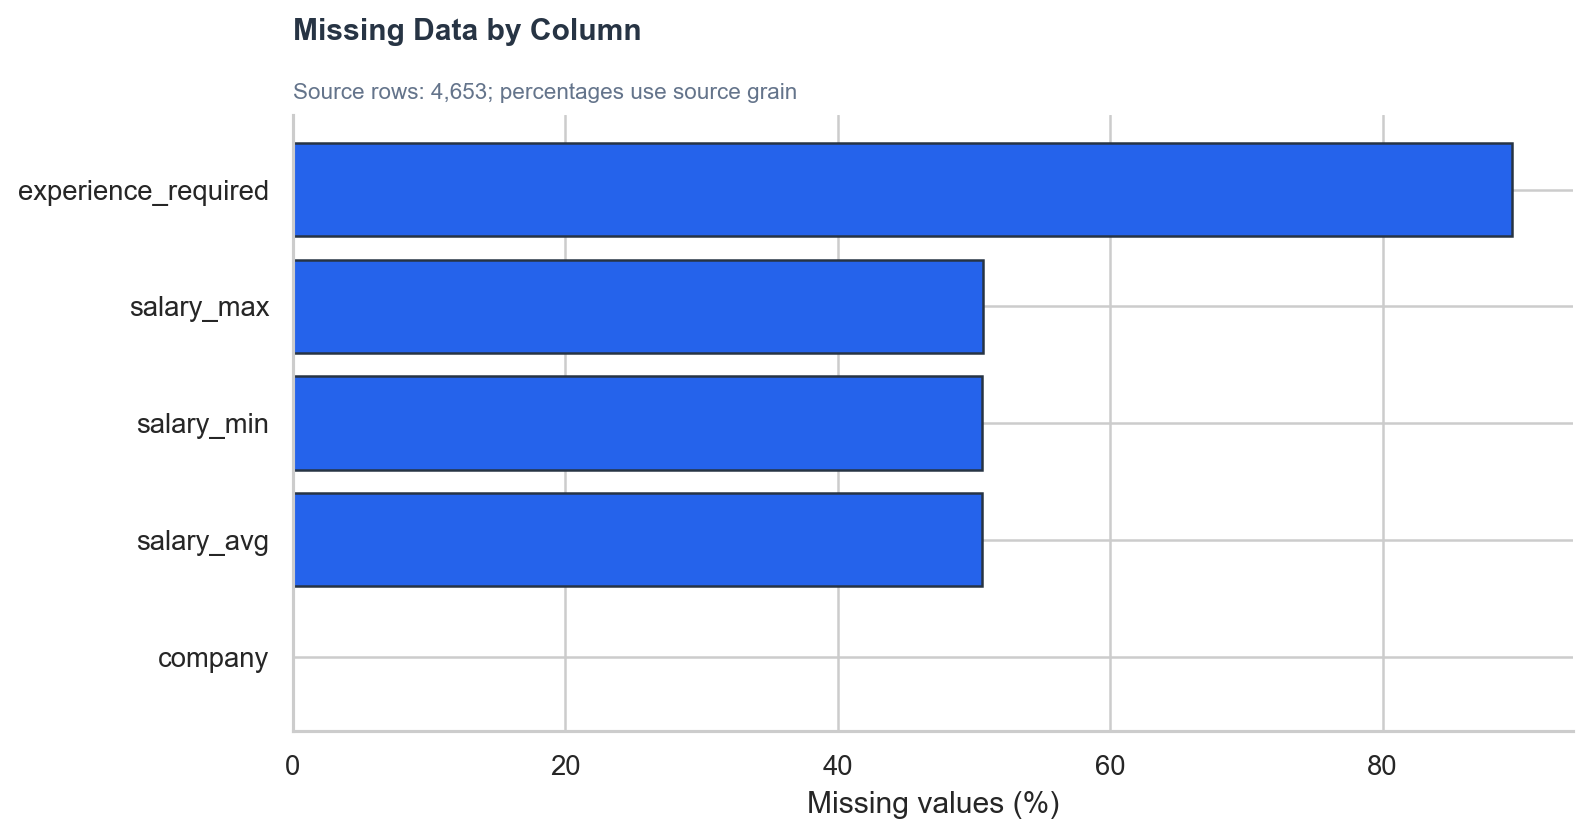

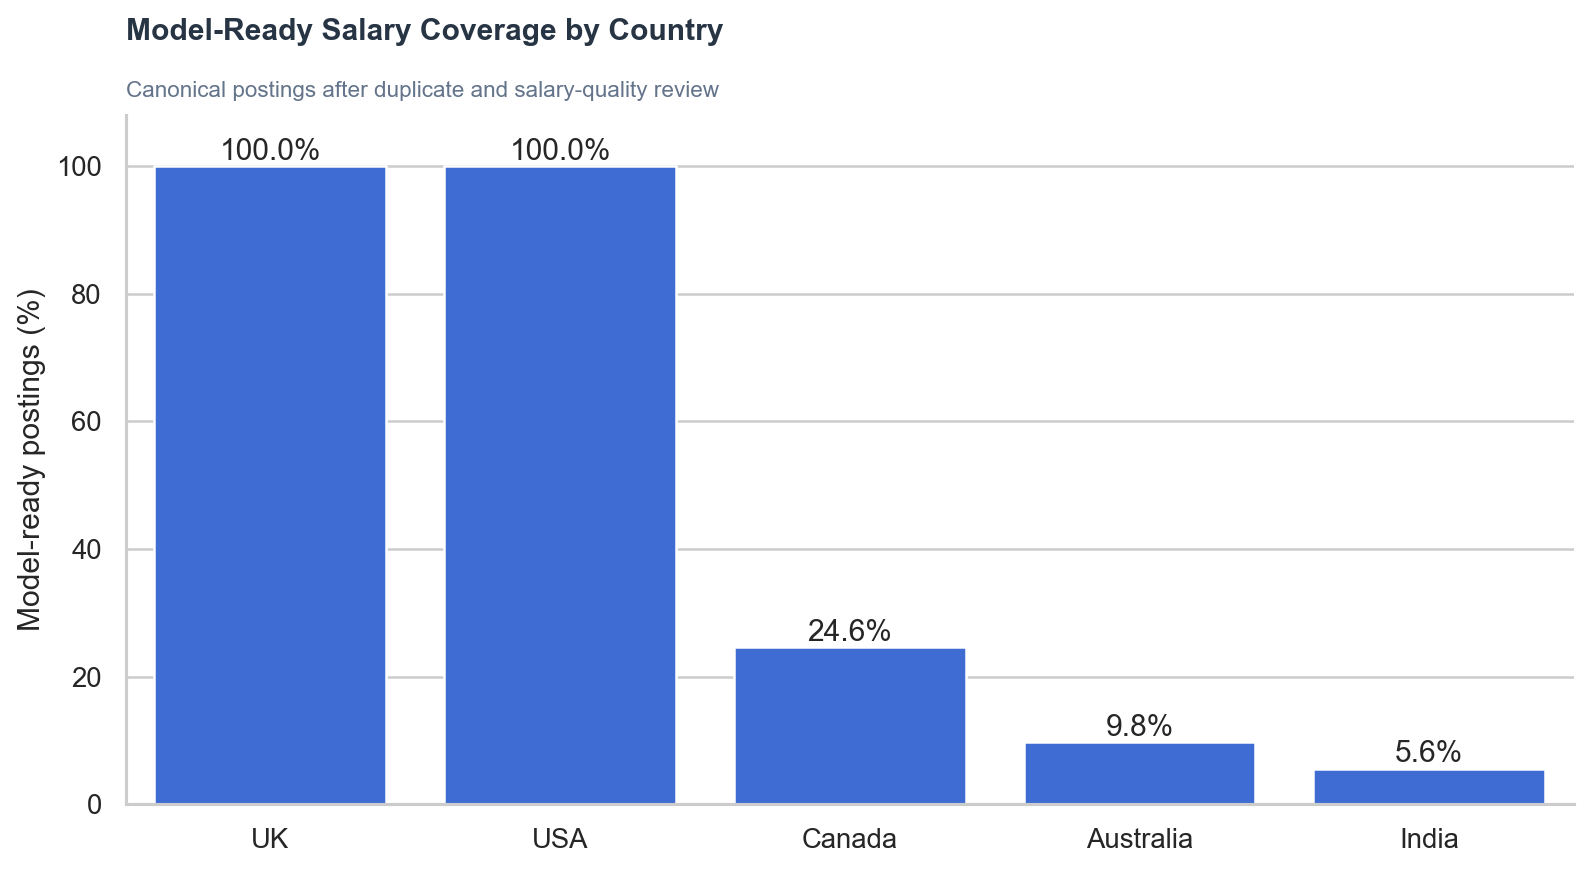

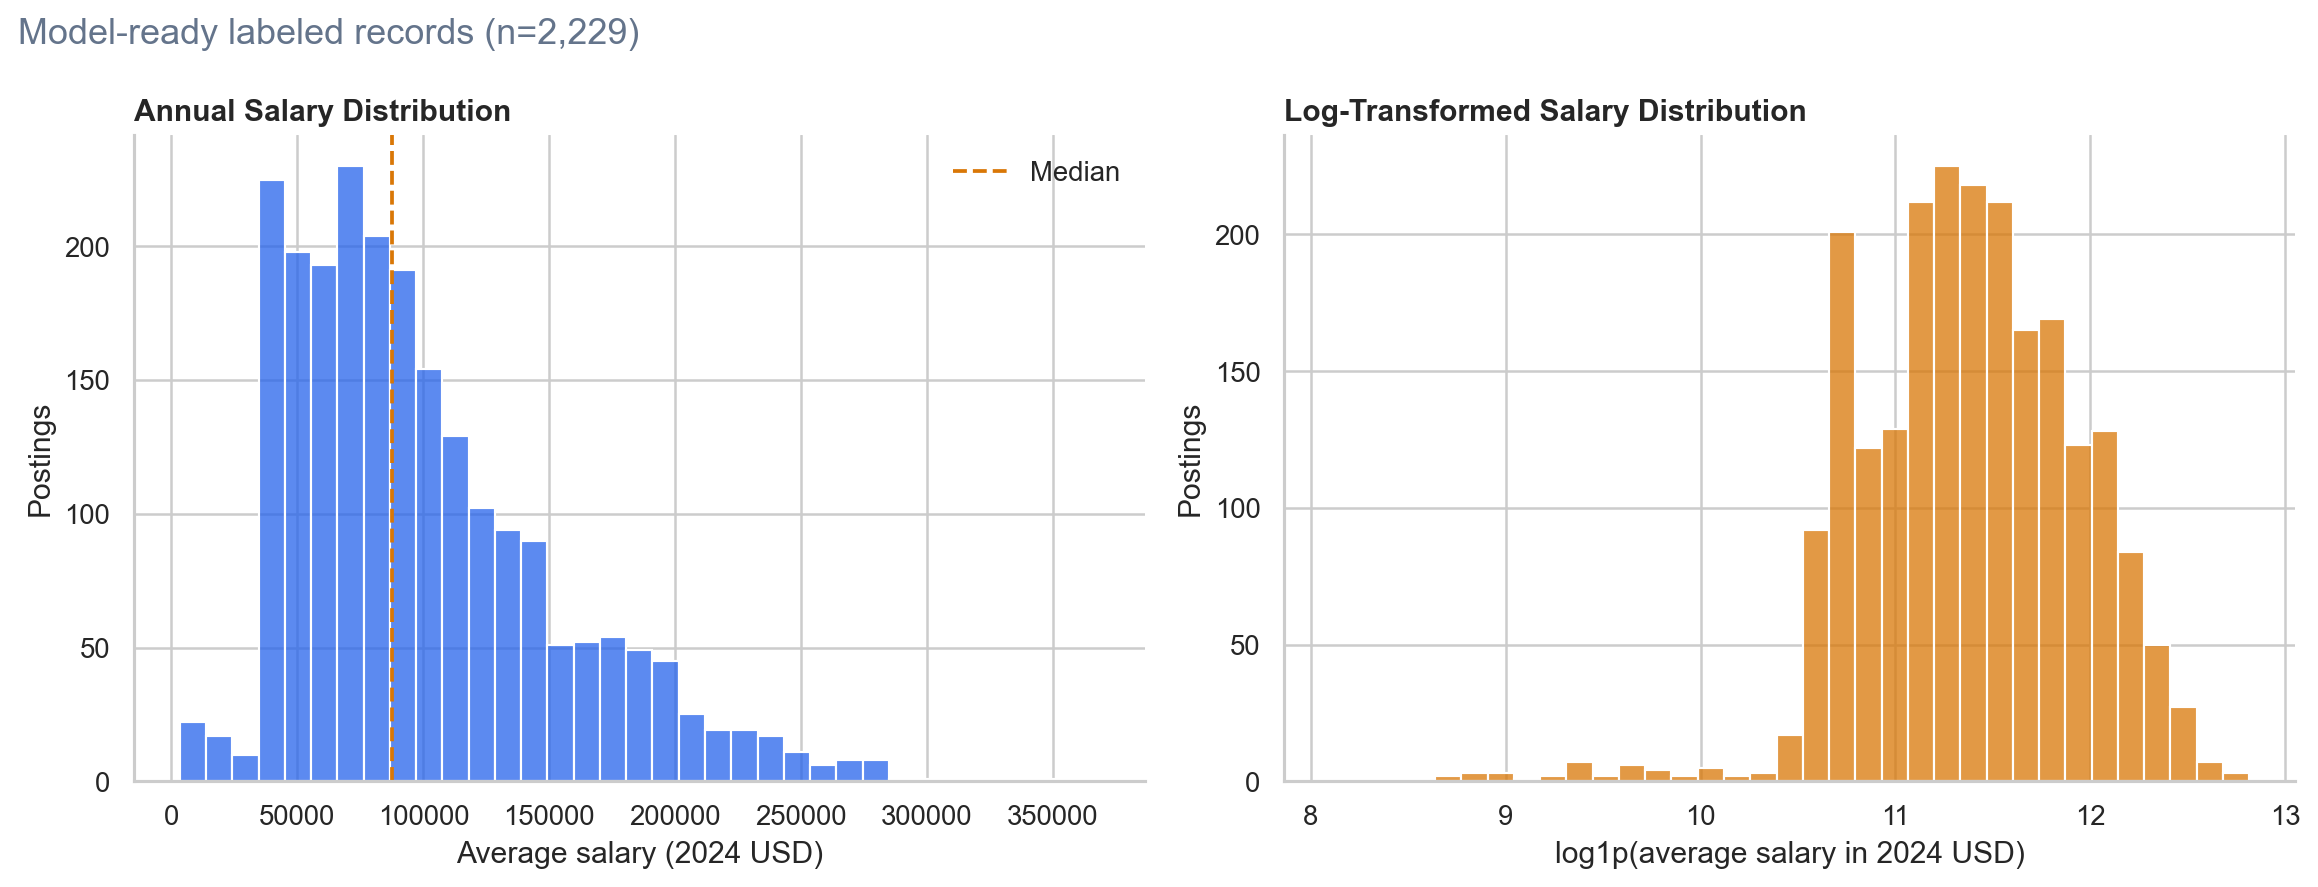

In [12]:
display(Image(filename=str(paths["figures"] / "01_missing_data_by_column.png"), width=900))
display(Image(filename=str(paths["figures"] / "02_salary_coverage_by_country.png"), width=950))
display(Image(filename=str(paths["figures"] / "03_salary_distribution_and_log.png"), width=1100))

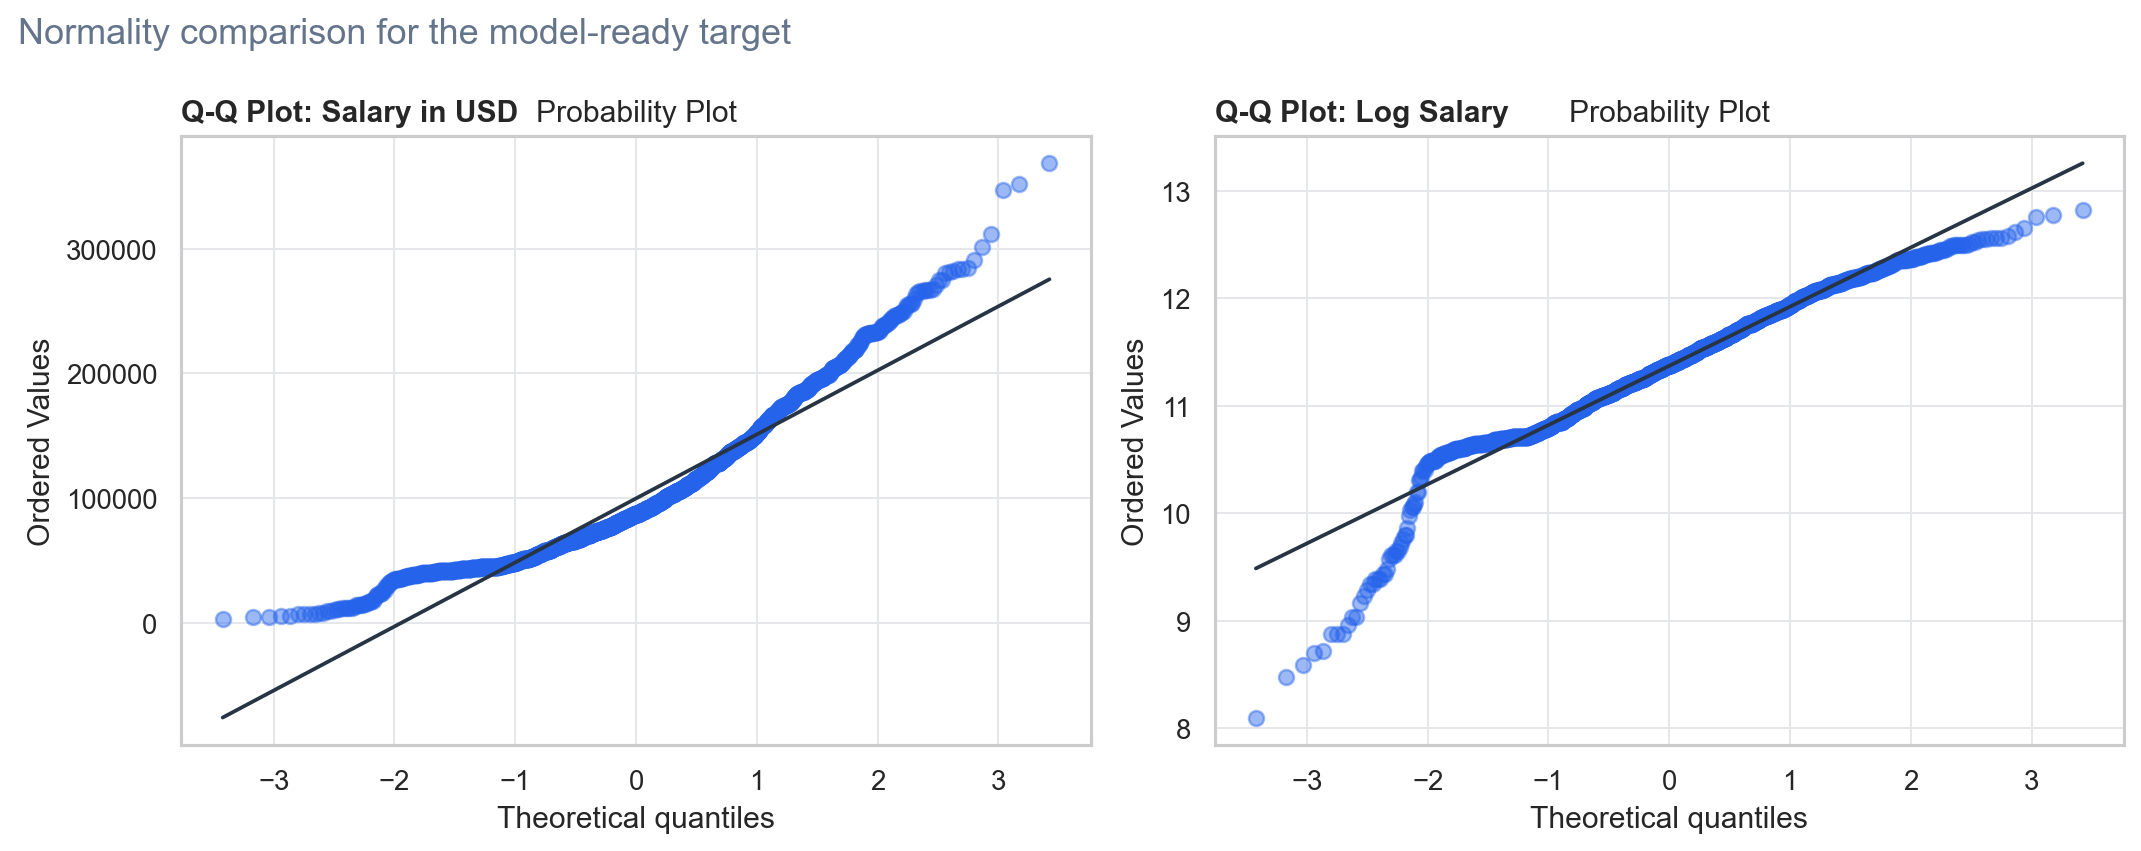

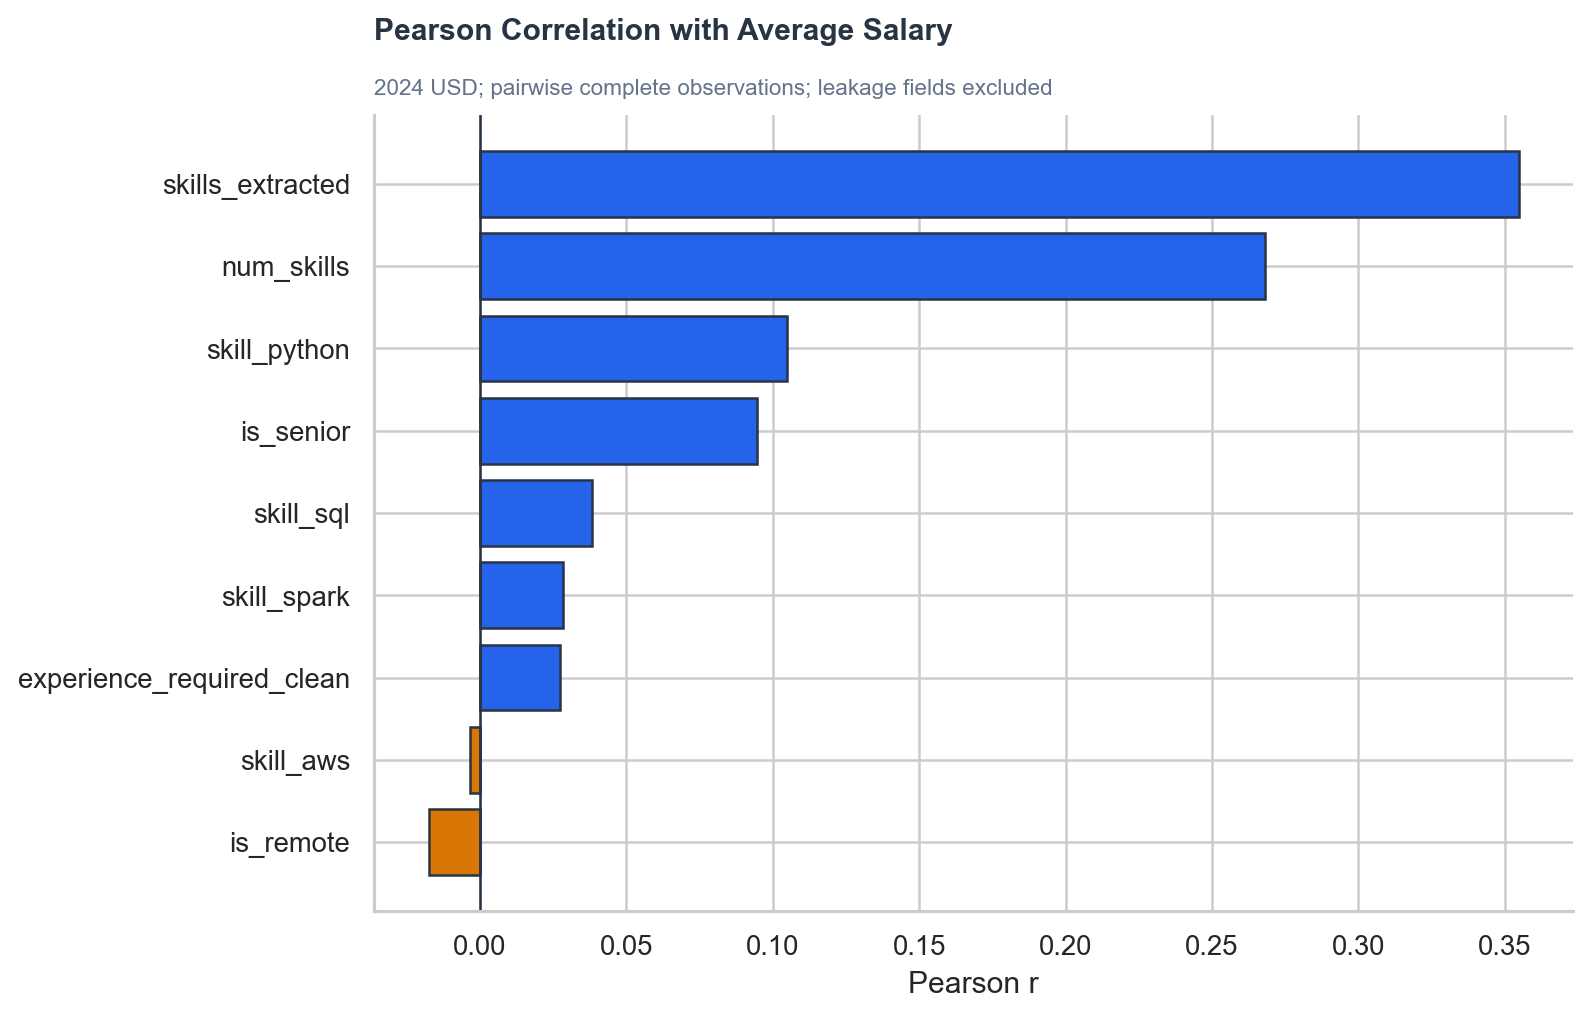

In [13]:
display(Image(filename=str(paths["figures"] / "04_salary_qq_before_after_log.png"), width=1050))
display(Image(filename=str(paths["figures"] / "05_numeric_feature_correlations.png"), width=900))

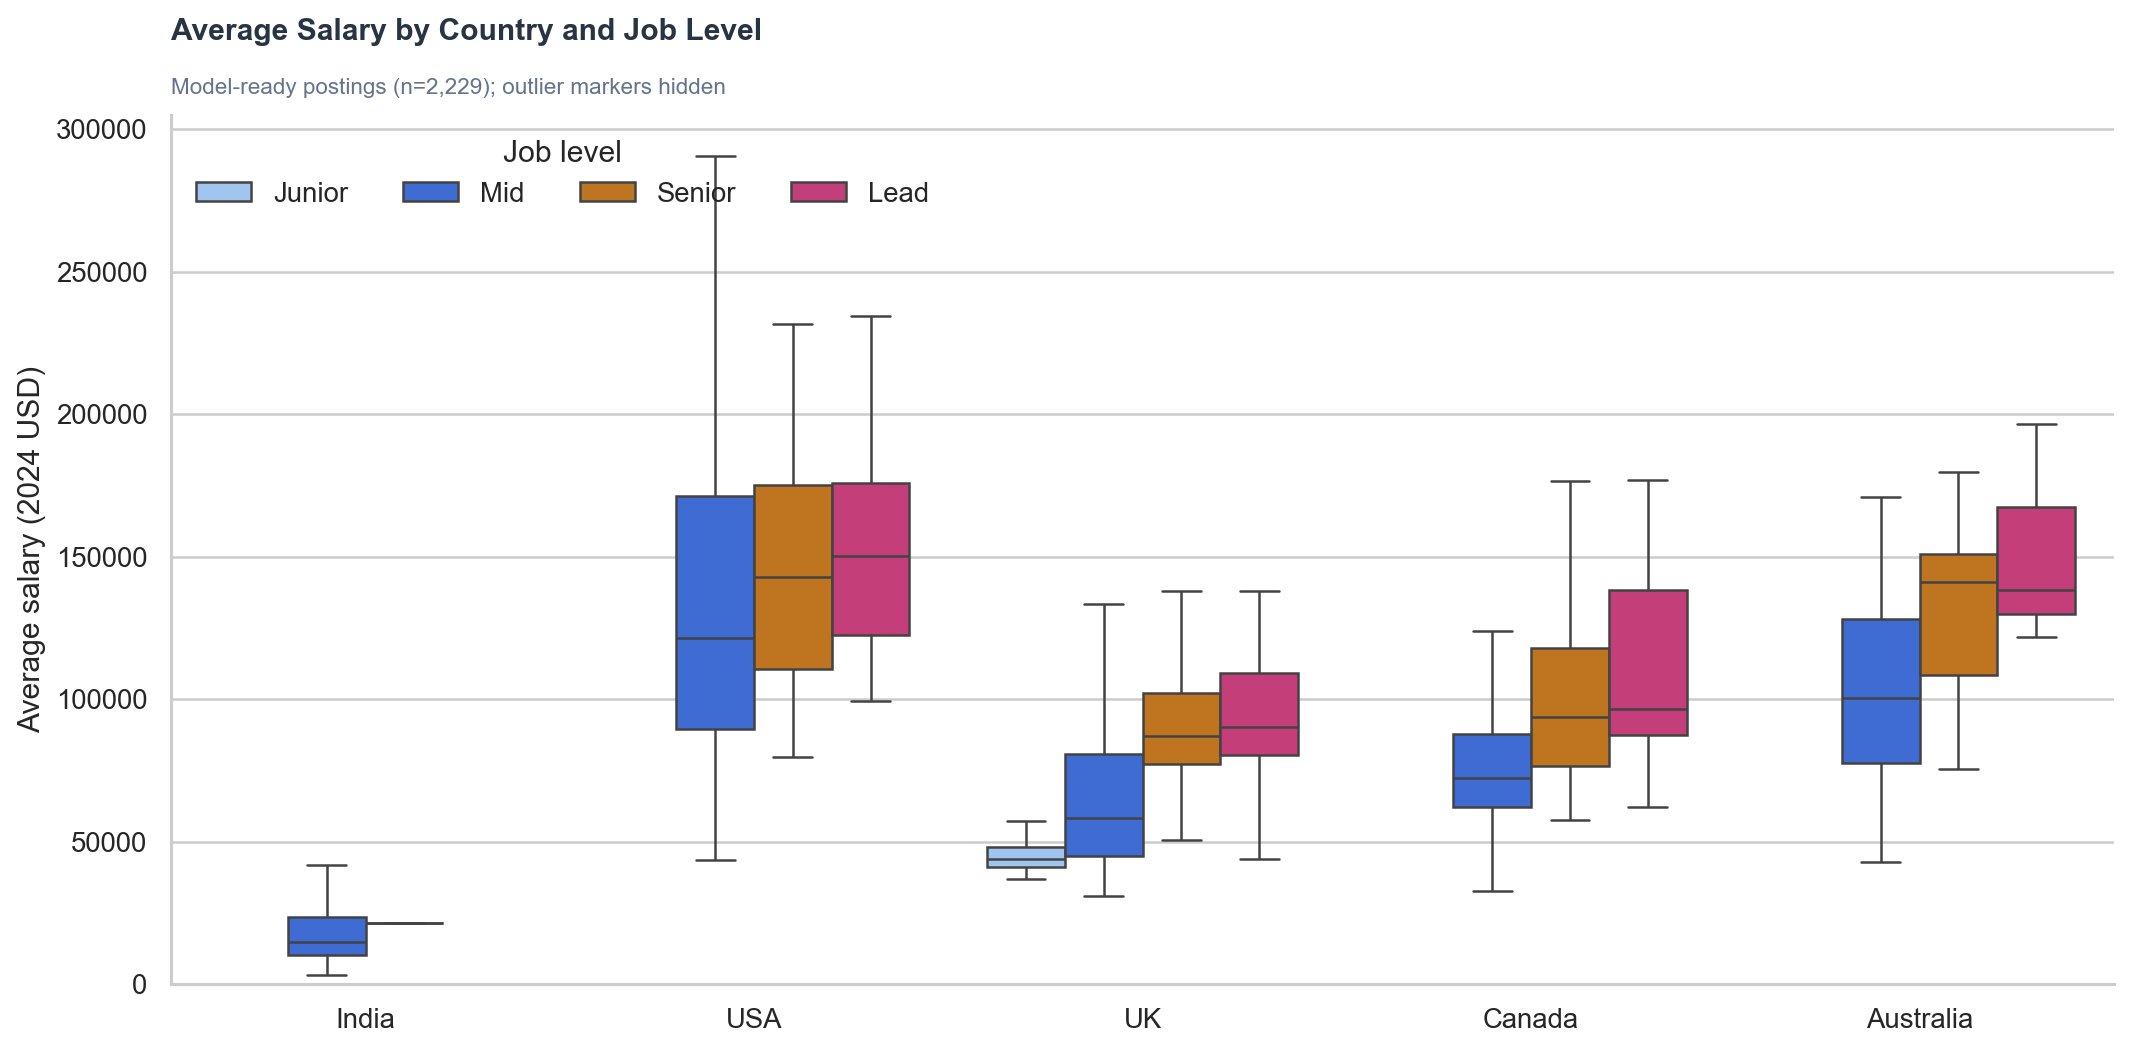

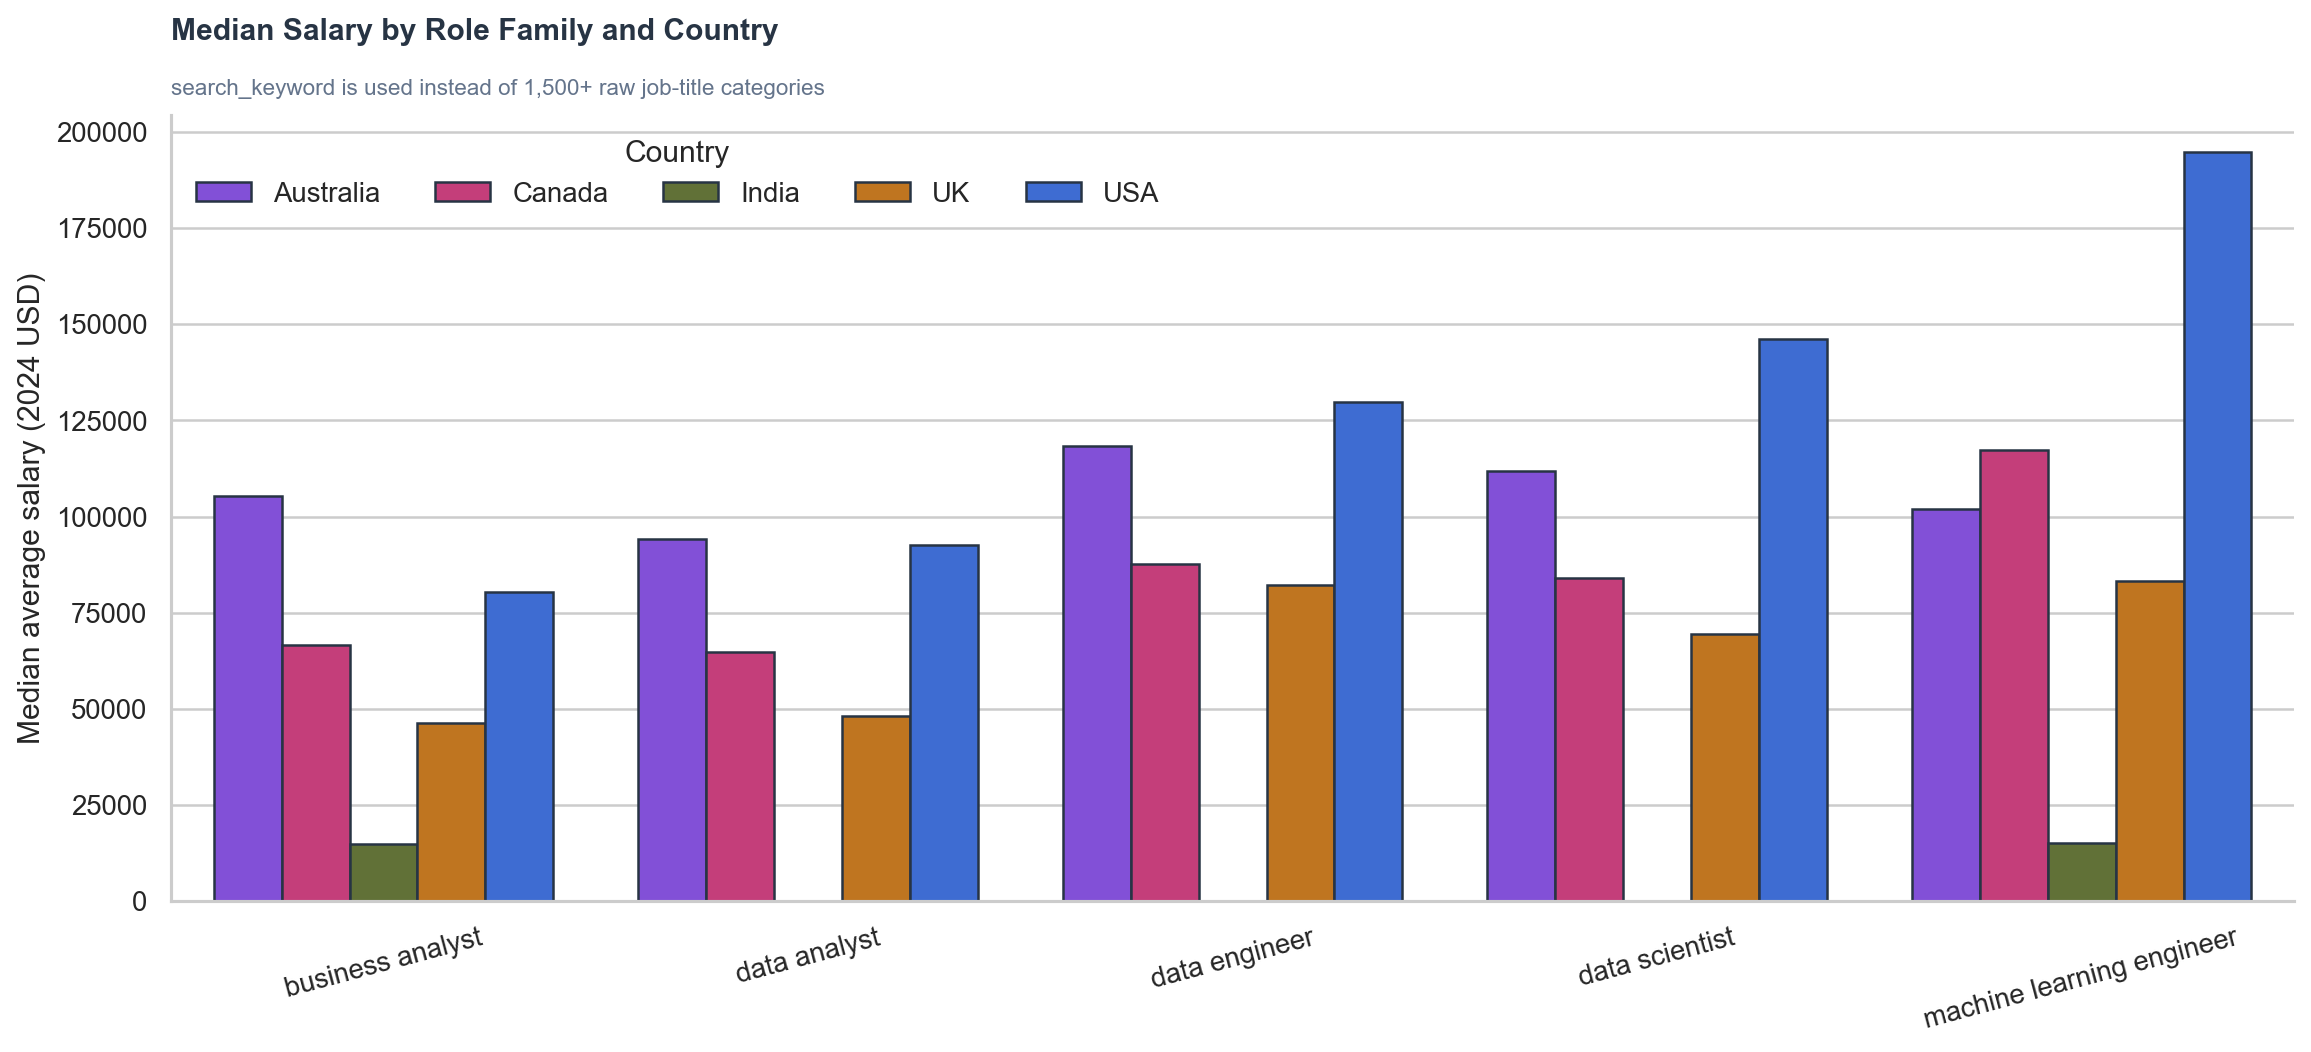

In [14]:
display(Image(filename=str(paths["figures"] / "06_salary_by_country_and_job_level.png"), width=1100))
display(Image(filename=str(paths["figures"] / "07_salary_by_role_family_country.png"), width=1100))

### 5. VIF and multicollinearity

`num_skills` is the sum of the eight individual skill flags, so including all of them together creates perfect linear dependence. The final nonredundant feature candidates therefore compare the count and specific flags separately.

,feature,VIF
0,num_skills,inf
1,skill_python,inf
2,skill_sql,inf
3,skill_spark,inf
4,skill_aws,inf
5,skill_excel,inf
6,skill_machine_learning,inf
7,skill_power_bi,inf
8,skill_tableau,inf
9,skills_extracted,9.38


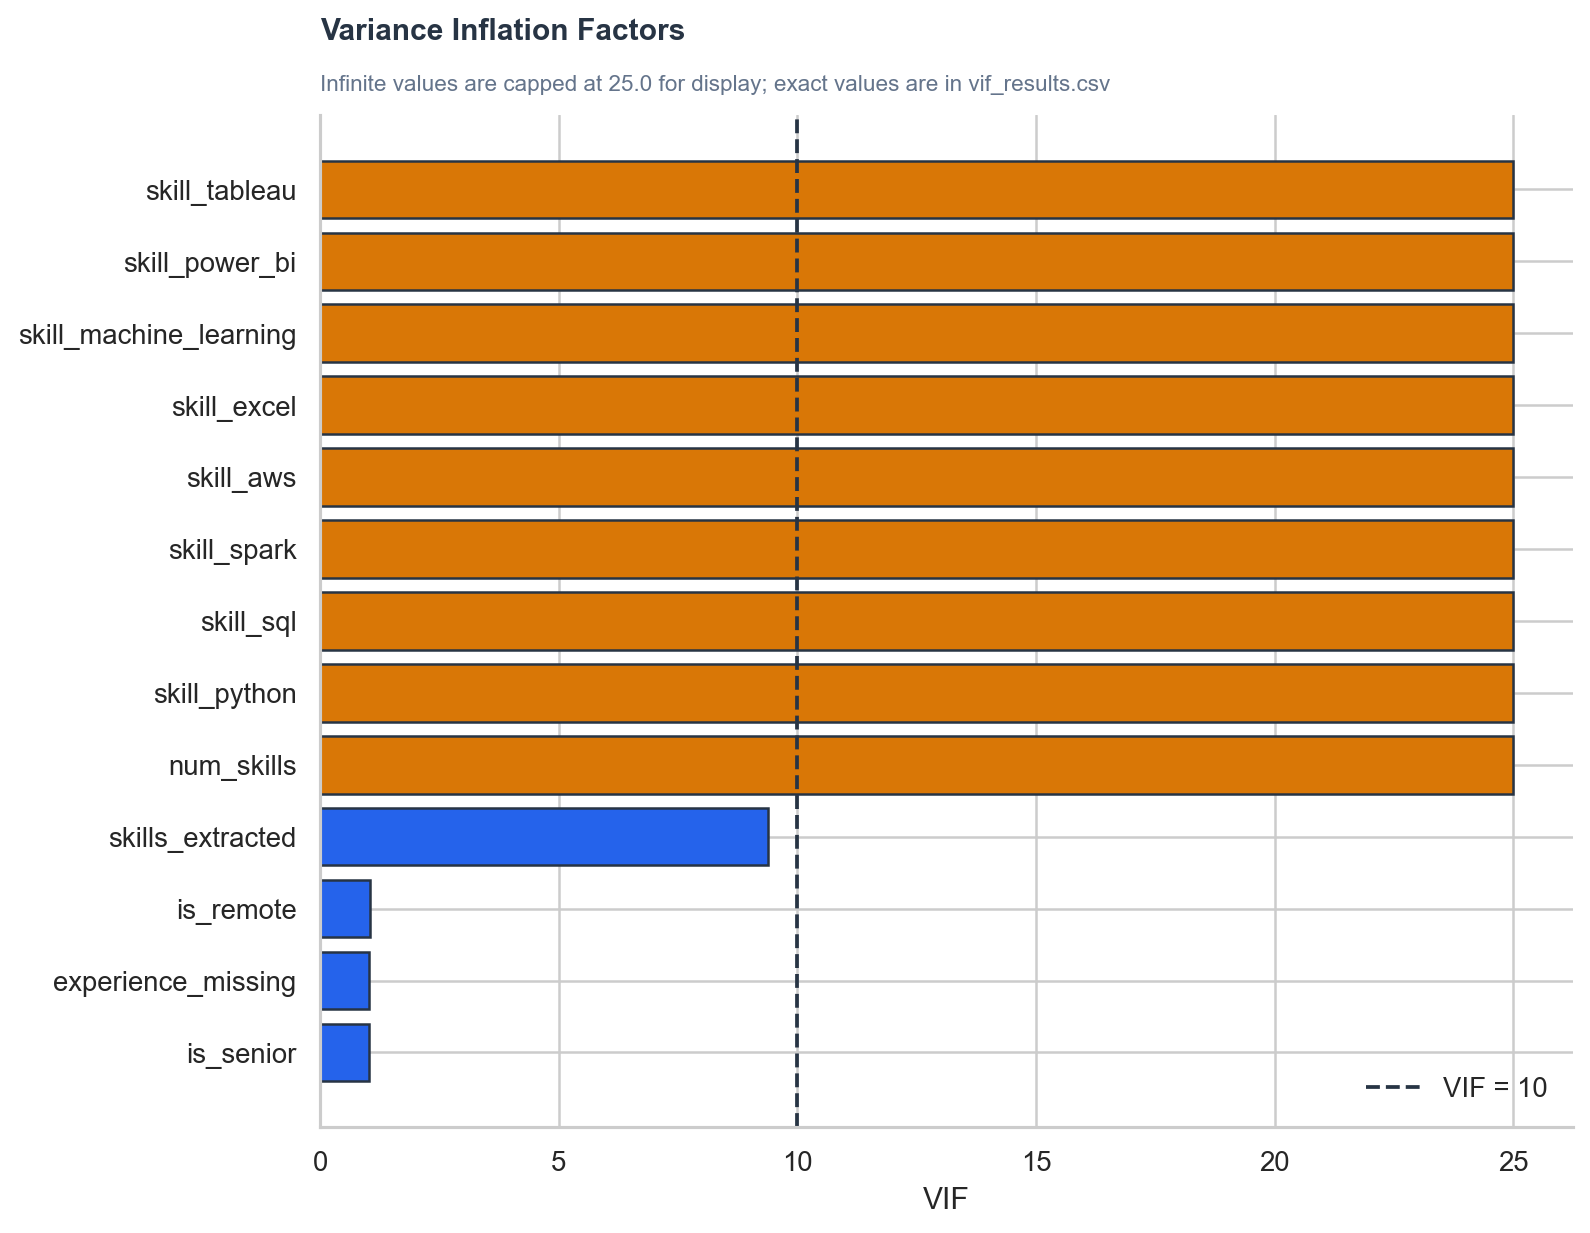

In [15]:
vif = calculate_vif(training, paths["processed"], paths["figures"])
display(vif)
display(Image(filename=str(paths["figures"] / "08_vif_results.png"), width=900))

### 6. Create the development and locked final holdout split

In [16]:
development, test = train_test_split(
    training,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=training["country"],
)
y_dev = development["salary_avg_usd"].copy()
y_test = test["salary_avg_usd"].copy()
stratified_cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
cv_splits = list(stratified_cv.split(development, development["country"]))

print(f"Development rows: {len(development):,}")
print(f"Locked holdout rows: {len(test):,}")
display(pd.crosstab(development["country"], columns="development"))
display(pd.crosstab(test["country"], columns="holdout"))

Development rows: 1,783
Locked holdout rows: 446


col_0,development
country,
Australia,70
Canada,181
India,41
UK,741
USA,750


col_0,holdout
country,
Australia,18
Canada,45
India,10
UK,185
USA,188


### 7. Determine which engineered features improve cross-validated R2

Selected feature set: Engineered + job-title text


,Feature_Set,CV_MAE,CV_MAE_SD,CV_RMSE,CV_R2,Train_MAE
0,Engineered + job-title text,"22,473.71","1,232.74","32,055.34",0.63,"21,703.23"
1,Core + num_skills,"23,251.68","1,289.73","32,840.77",0.61,"23,047.68"
2,Core,"23,325.36","1,311.81","32,902.14",0.61,"23,158.72"
3,Core + top skills,"23,375.70","1,223.19","32,980.01",0.61,"23,063.39"
4,Core + nonredundant engineered,"23,469.89","1,129.22","33,088.38",0.61,"23,050.76"


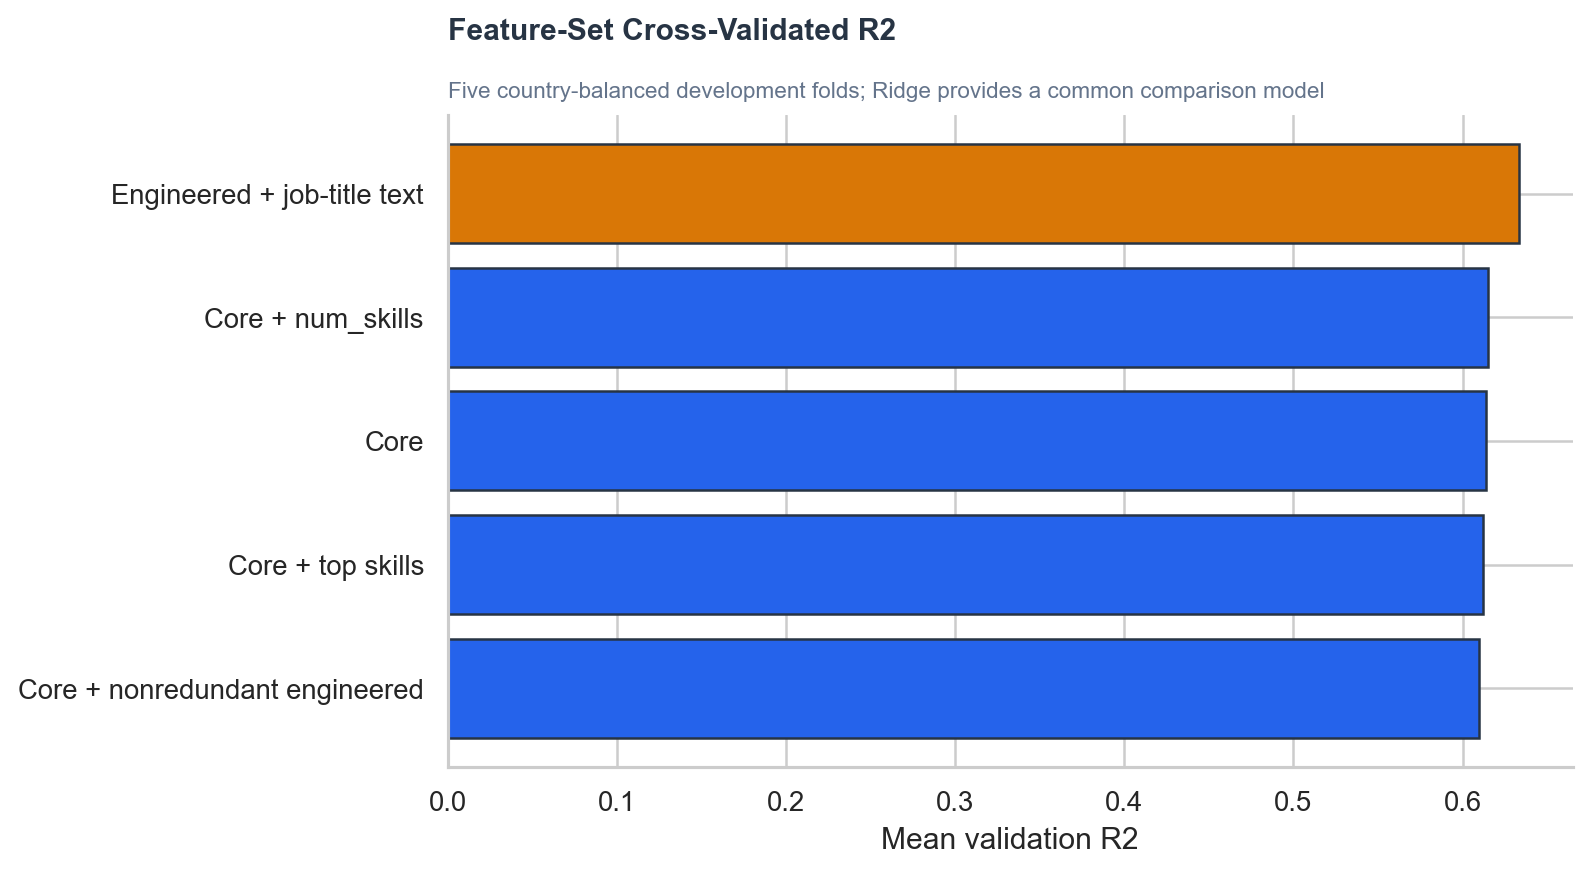

In [17]:
selected_feature_set, feature_results = feature_set_ablation(
    development,
    y_dev,
    cv_splits,
    paths["processed"],
    paths["figures"],
)
selected_spec = FEATURE_SPECS[selected_feature_set]
print(f"Selected feature set: {selected_feature_set}")
display(feature_results.round(3))
display(Image(filename=str(paths["figures"] / "09_feature_set_ablation.png"), width=900))

### 8. Select Ridge alpha and inspect Random Forest depth 3-20

In [18]:
best_alpha, ridge_results = ridge_alpha_analysis(
    selected_spec,
    development,
    y_dev,
    cv_splits,
    paths["processed"],
    paths["figures"],
)
overfit_text, depth_results = random_forest_depth_analysis(
    selected_spec,
    development,
    y_dev,
    paths["processed"],
    paths["figures"],
)
print(f"Best Ridge alpha: {best_alpha:g}")
print(f"Random Forest overfitting result: {overfit_text}")
display(ridge_results.round(2))
display(depth_results.round(2))

Best Ridge alpha: 1
Random Forest overfitting result: not detected through depth 20


,alpha,CV_MAE,Train_MAE
0,0.01,"22,511.71","19,850.23"
1,0.10,"22,296.31","19,929.18"
2,1.00,"22,019.51","20,368.60"
3,10.00,"22,473.71","21,703.23"
4,100.00,"24,837.10","24,485.87"
5,"1,000.00","32,610.54","32,461.69"


,max_depth,Train_MAE,Validation_MAE,MAE_Gap
0,3,"23,186.74","23,038.85",-147.89
1,4,"21,621.26","21,882.20",260.94
2,5,"20,478.38","21,212.26",733.88
3,6,"19,642.87","20,779.37","1,136.51"
4,7,"18,973.76","20,449.18","1,475.42"
5,8,"18,493.21","20,204.74","1,711.53"
6,9,"18,152.22","20,088.17","1,935.95"
7,10,"17,935.52","20,038.73","2,103.21"
8,11,"17,753.78","20,023.66","2,269.88"
9,12,"17,644.23","20,021.00","2,376.76"


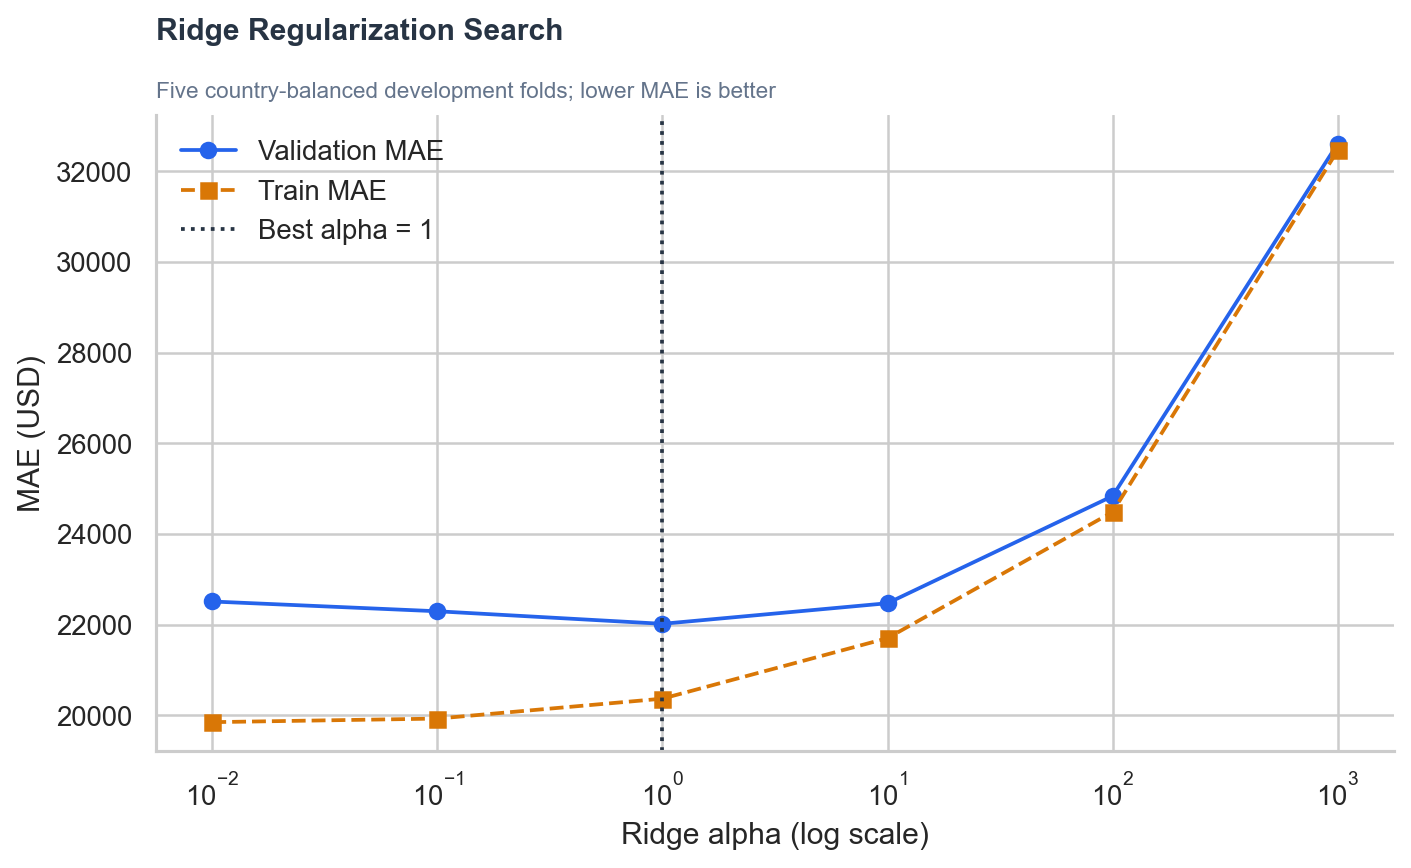

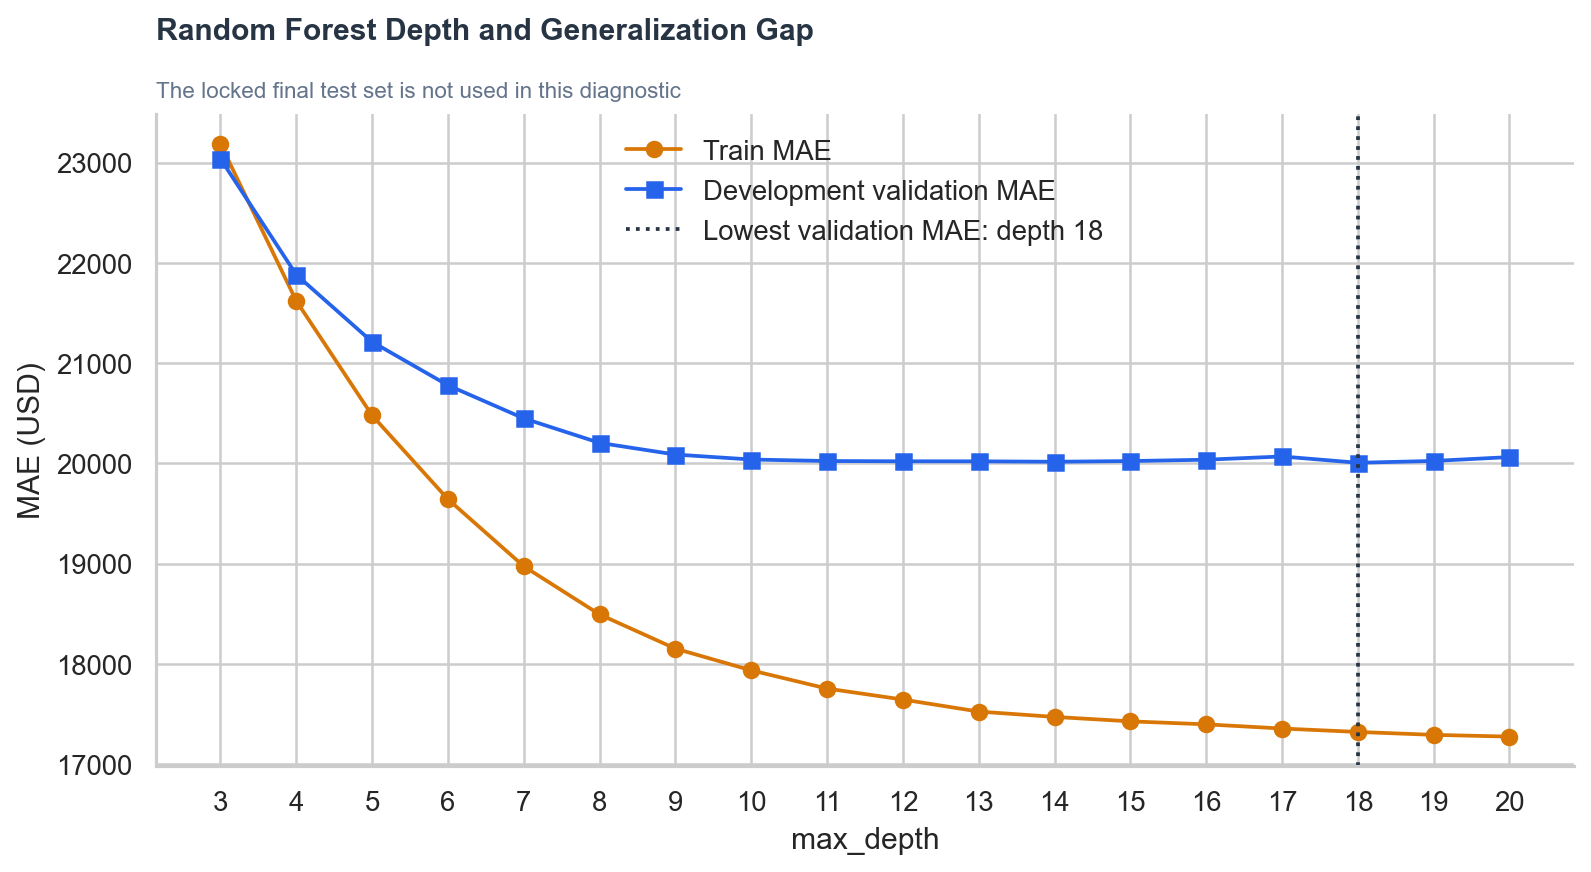

In [19]:
display(Image(filename=str(paths["figures"] / "10_ridge_alpha_search.png"), width=850))
display(Image(filename=str(paths["figures"] / "11_random_forest_depth_gap.png"), width=950))

### 9. Compare the three required algorithms

Strongest development model: Random Forest


,Model,CV_MAE,CV_MAE_SD,CV_RMSE,CV_R2,Train_MAE
0,Random Forest,"20,709.16","1,626.92","30,263.84",0.67,"16,917.45"
1,Gradient Boosting,"20,971.35","1,279.05","30,108.79",0.68,"19,284.61"
2,Linear Regression,"22,581.38","1,101.97","32,347.36",0.63,"19,838.16"


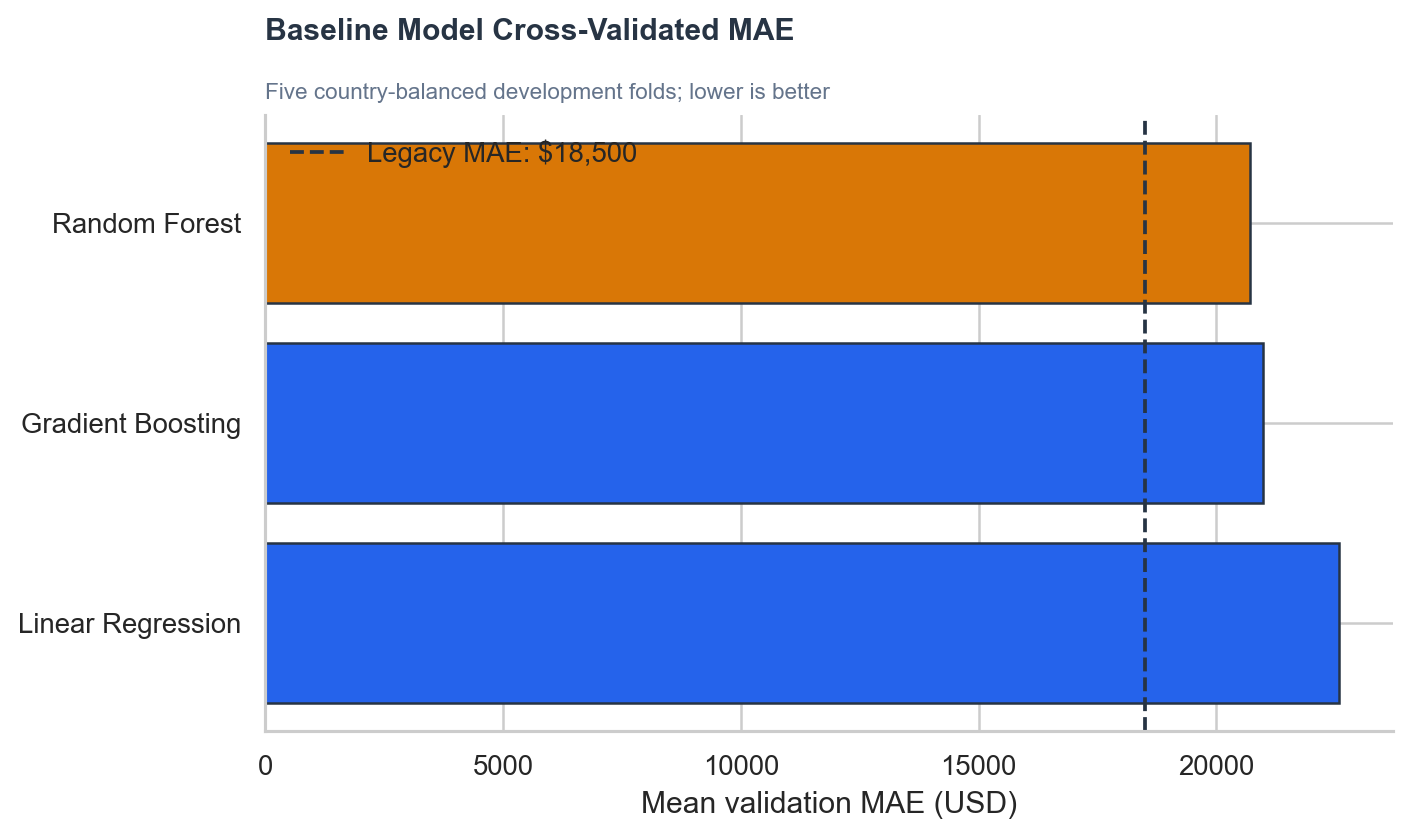

In [20]:
strongest, baseline_pipelines, baseline_results = compare_baseline_models(
    selected_spec,
    development,
    y_dev,
    cv_splits,
    paths["processed"],
    paths["figures"],
)
print(f"Strongest development model: {strongest}")
display(baseline_results.round(2))
display(Image(filename=str(paths["figures"] / "12_baseline_model_cv_comparison.png"), width=850))

### 10. Tune the strongest model and compare original versus log target

In [21]:
tuned_model, tuning_results = tune_strongest_model(
    strongest,
    selected_spec,
    development,
    y_dev,
    cv_splits,
    paths["processed"],
)
selected_model, selected_target, target_results = compare_target_scales(
    tuned_model,
    development[selected_spec.columns],
    y_dev,
    cv_splits,
    paths["processed"],
)
best_parameters = json.loads(
    (paths["processed"] / "best_hyperparameters.json").read_text(encoding="utf-8")
)
print("Best hyperparameters:", best_parameters)
print(f"Selected target: {selected_target}")
display(target_results.round(2))

Best hyperparameters: {'model__max_depth': 14, 'model__max_features': 0.7, 'model__min_samples_leaf': 1, 'model__n_estimators': 500}
Selected target: Log target


,Target,CV_MAE,CV_MAE_SD,CV_RMSE,CV_R2,Train_MAE
0,"Log target, predictions returned to USD","20,006.12","1,651.04","30,021.44",0.68,"15,824.17"
1,Original USD,"20,607.38","1,609.58","30,119.87",0.68,"16,122.15"


### 11. Open the final holdout once and evaluate algorithms and bias

In [22]:
_, test_results, audit, country_metrics, segment_metrics = final_evaluation(
    selected_spec,
    development,
    test,
    y_dev,
    y_test,
    baseline_pipelines,
    selected_model,
    selected_target,
    paths["processed"],
    paths["figures"],
)
display(test_results.round(3))
display(country_metrics.round(2))
display(segment_metrics.round(2))

,Model,MAE,RMSE,R2
0,Random Forest,"20,467.05","29,630.45",0.70
1,Gradient Boosting,"21,213.45","30,103.37",0.70
2,Tuned final candidate (Log target),"20,175.04","30,193.90",0.69
3,Linear Regression,"22,481.16","32,283.67",0.65


,country,Rows,MAE,RMSE,R2,Mean_Residual,Underprediction_Rate
0,Australia,18.00,"29,983.94","35,636.61",-0.26,"9,680.97",55.56
1,Canada,45.00,"16,220.55","23,369.65",0.41,"1,919.14",37.78
2,India,10.00,"10,321.17","15,548.21",-0.49,"6,455.41",50.00
3,UK,185.00,"15,500.98","25,002.49",0.36,"3,176.31",45.95
4,USA,188.00,"25,306.07","35,811.58",0.59,"7,356.11",49.47


,salary_segment,Rows,MAE,RMSE,R2,Mean_Residual,Underprediction_Rate
0,Premium,67.00,"20,765.41","26,663.99",0.48,"2,049.58",47.76
1,Standard,379.00,"20,070.68","30,775.83",0.71,"5,695.03",46.97


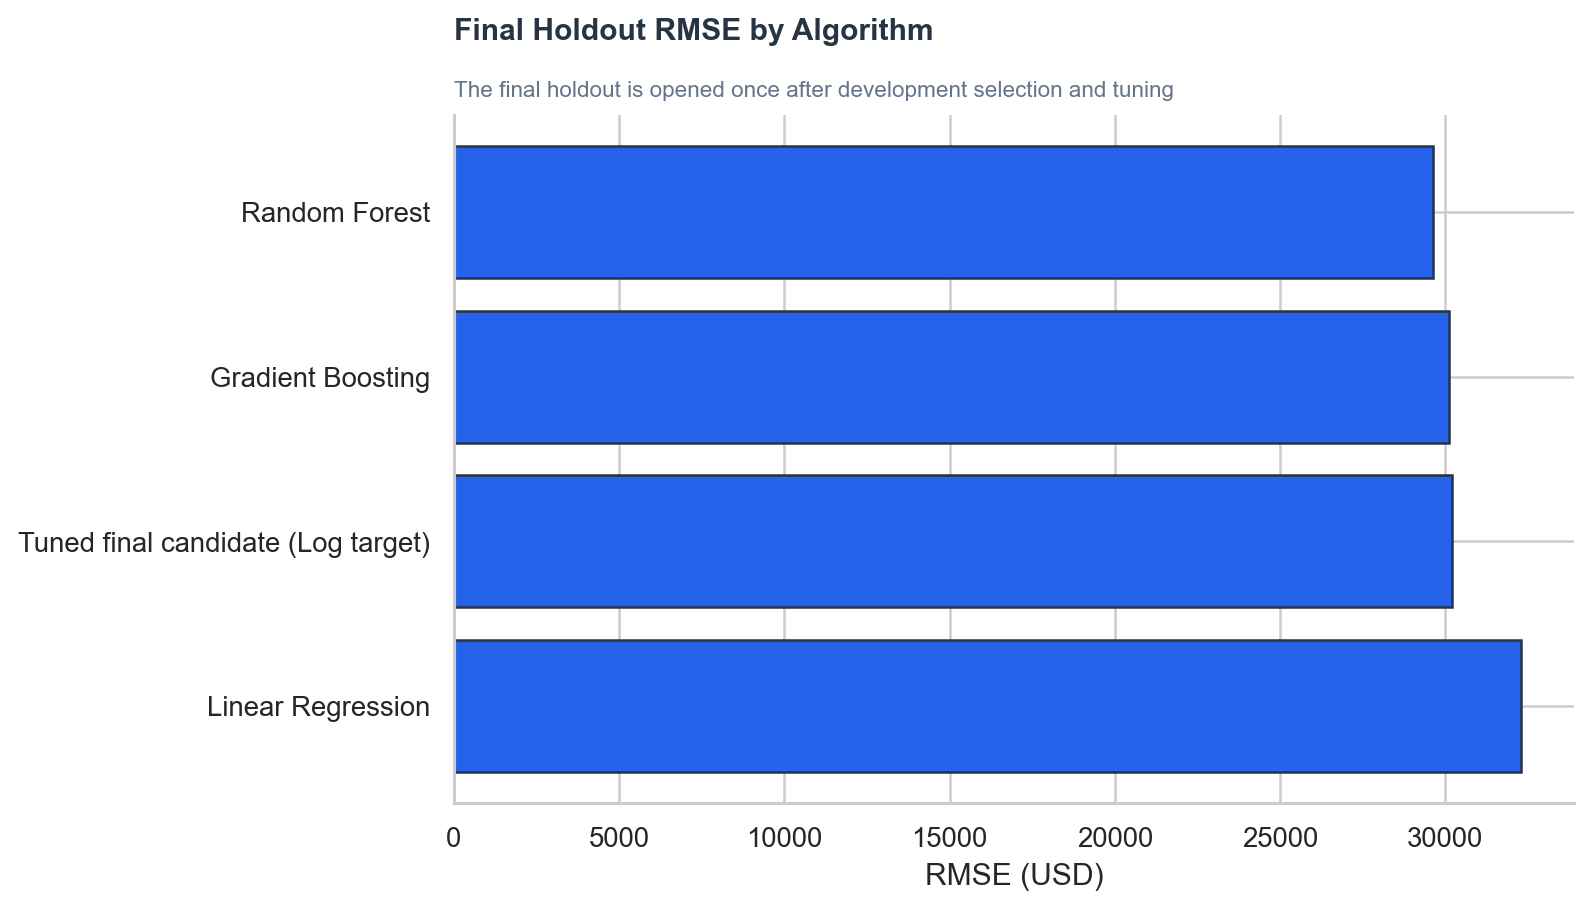

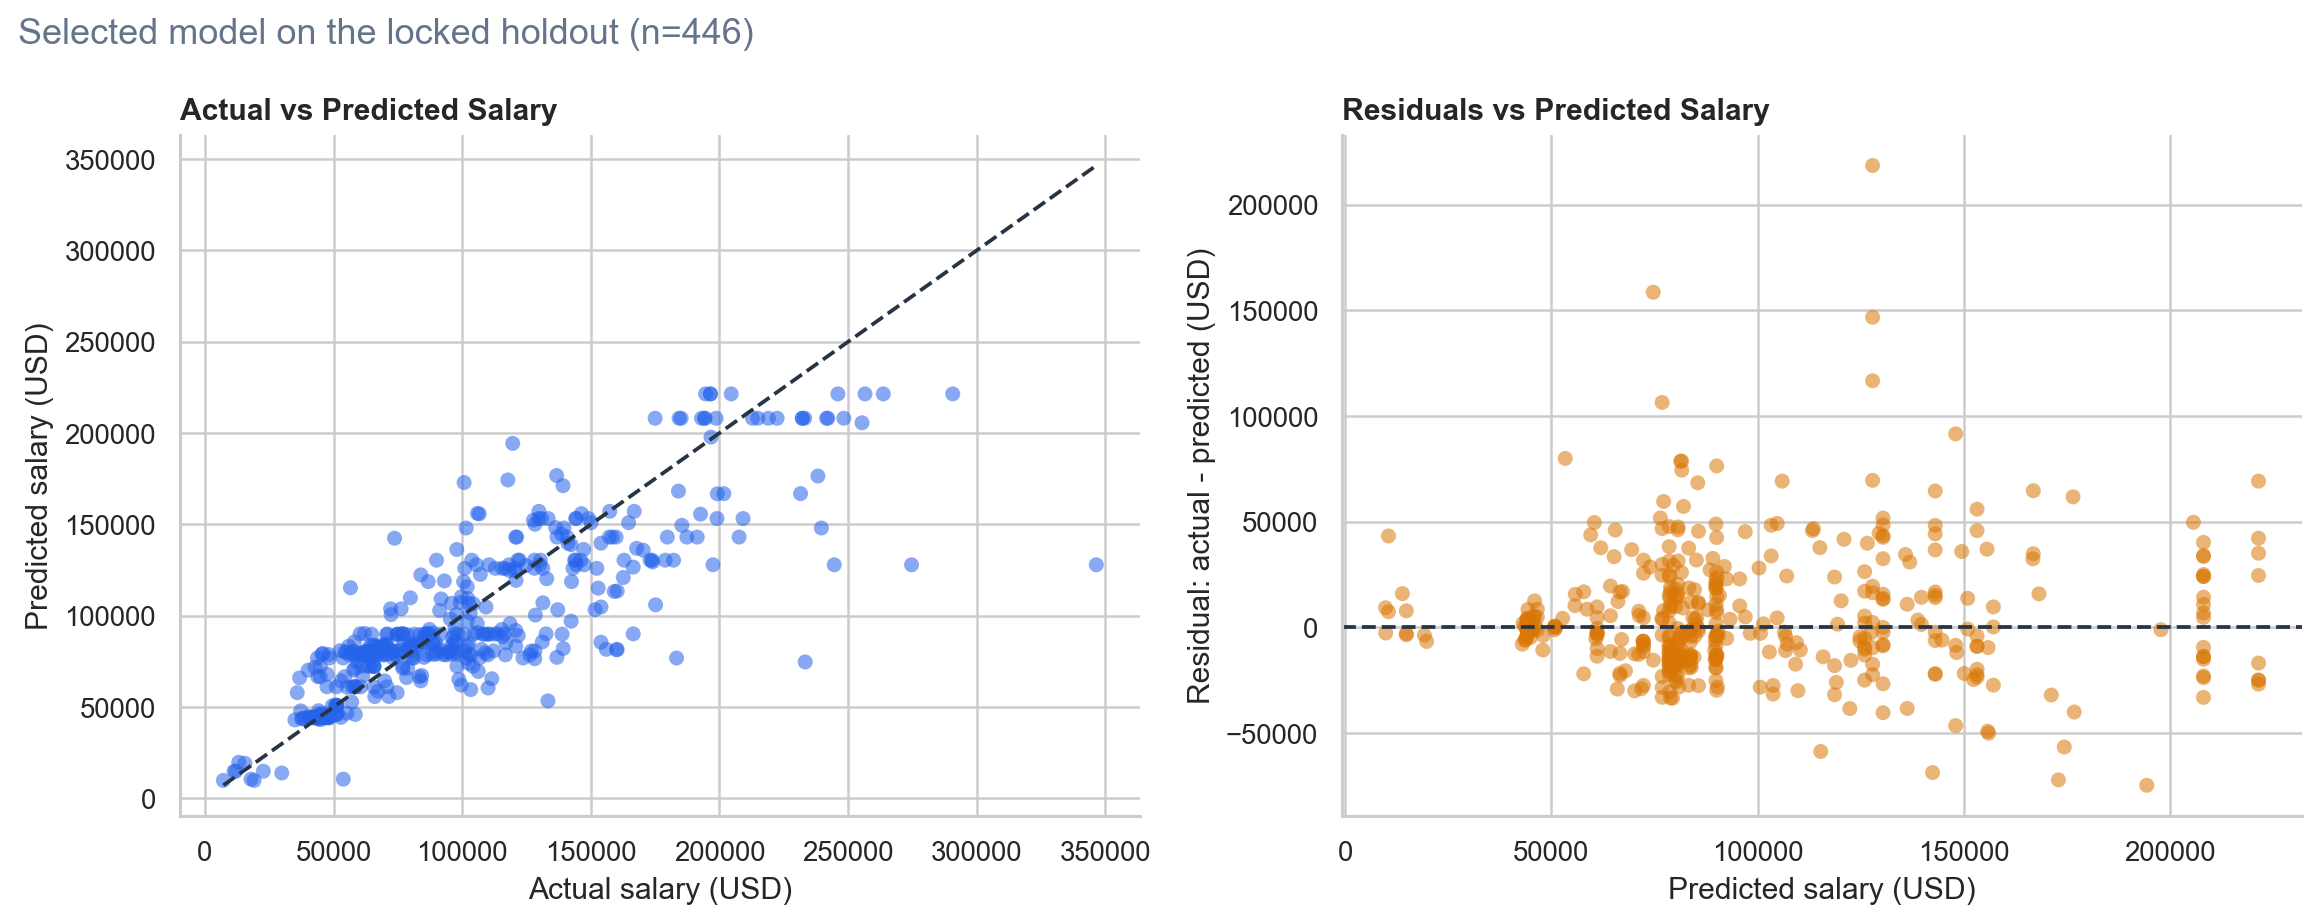

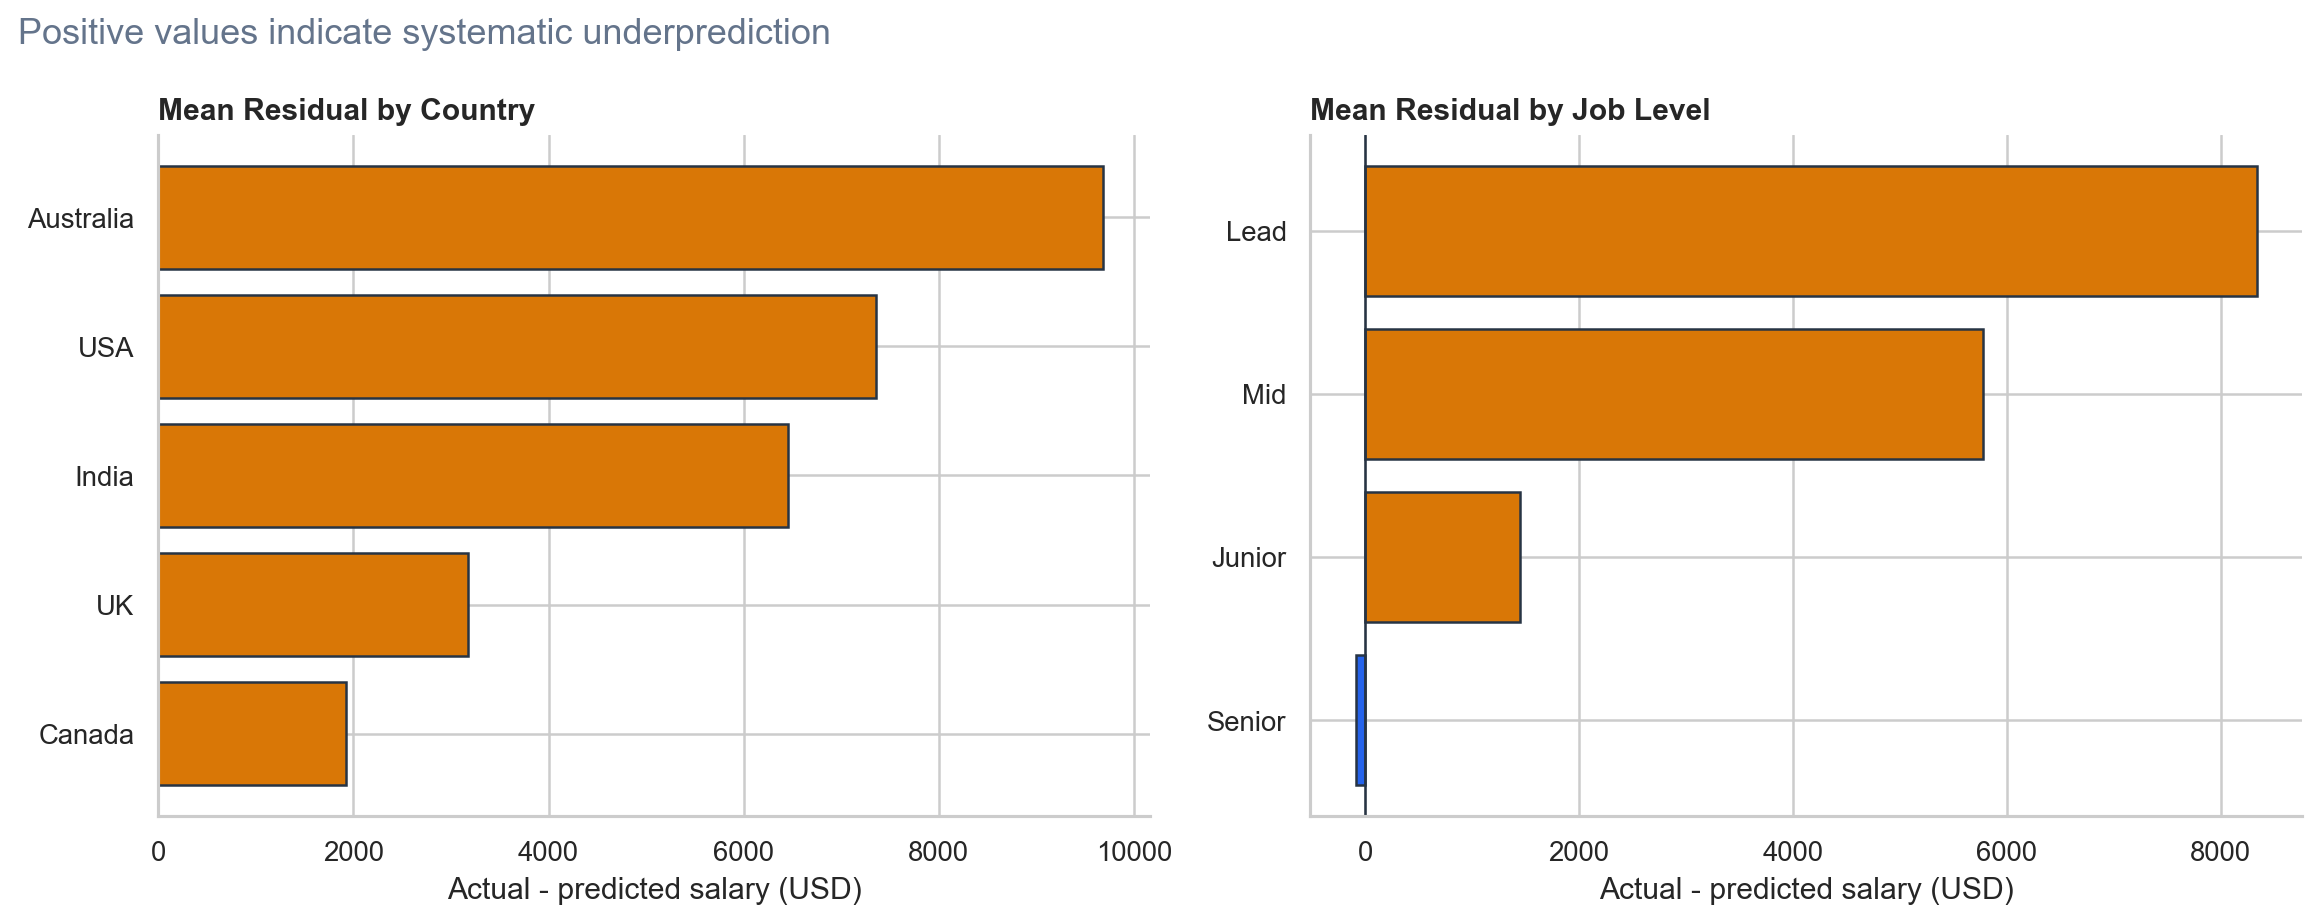

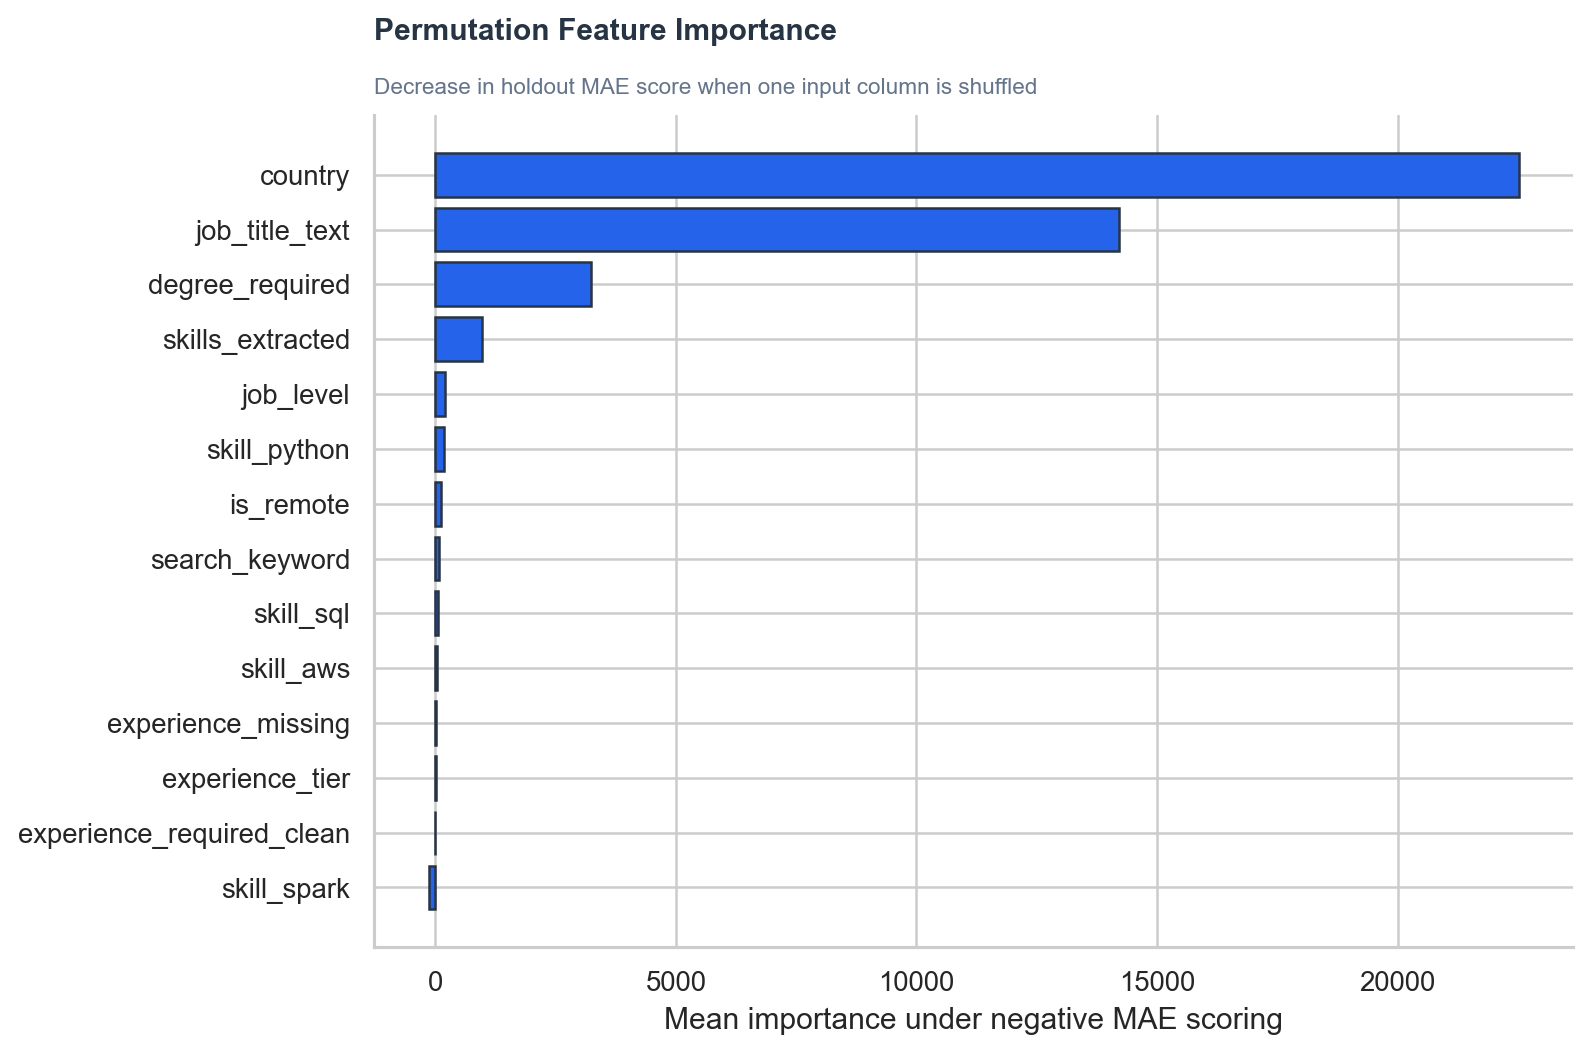

In [23]:
display(Image(filename=str(paths["figures"] / "13_final_holdout_model_rmse.png"), width=900))
display(Image(filename=str(paths["figures"] / "14_final_holdout_residual_diagnostics.png"), width=1100))
display(Image(filename=str(paths["figures"] / "15_residual_bias_by_country_and_level.png"), width=1100))
display(Image(filename=str(paths["figures"] / "16_permutation_feature_importance.png"), width=900))

### 12. Refit on all approved labels, score unlabeled postings, and save the model

In [24]:
final_model = clone(selected_model).fit(
    training[selected_spec.columns],
    training["salary_avg_usd"],
)
scoring_predictions = scoring[
    ["job_id", "job_title", "company", "country", "job_level", "salary_segment"]
].copy()
scoring_predictions["predicted_salary_usd"] = final_model.predict(
    scoring[selected_spec.columns]
)
scoring_predictions.to_csv(
    paths["processed"] / "scoring_predictions.csv",
    index=False,
)
joblib.dump(final_model, paths["models"] / "talentpulse_salary_pipeline.joblib")
with (paths["models"] / "model_contract.json").open("w", encoding="utf-8") as stream:
    json.dump(
        {
            "selected_feature_set": selected_feature_set,
            "feature_columns": selected_spec.columns,
            "selected_target": selected_target,
            "legacy_mae_usd": LEGACY_MAE_USD,
            "industry_mae_usd": INDUSTRY_MAE_USD,
            "training_rows": len(training),
            "scoring_rows": len(scoring),
            "random_state": RANDOM_STATE,
        },
        stream,
        indent=2,
    )
display(scoring_predictions.head())

,job_id,job_title,company,country,job_level,salary_segment,predicted_salary_usd
0,5710345523,data scientist,Empnéo ICT,India,Mid,Standard,"16,268.46"
1,5676535670,data scientist,ADM,India,Mid,Standard,"14,951.89"
2,5705677339,data scientist,v4c.ai,India,Mid,Standard,"12,306.71"
3,5689758521,data scientist,Kotak Mahindra Bank,India,Mid,Standard,"16,290.25"
4,5709942304,data scientist,Whitefield Careers,India,Mid,Standard,"13,503.09"


### 13. Generate the HR benchmarking memo

In [25]:
write_benchmarking_memo(
    paths["reports"] / "benchmarking_memo.md",
    DATA_PATH,
    training,
    scoring,
    review,
    selected_feature_set,
    strongest,
    selected_target,
    overfit_text,
    best_alpha,
    test_results,
    audit,
    country_metrics,
    segment_metrics,
)
memo_text = (paths["reports"] / "benchmarking_memo.md").read_text(encoding="utf-8")
display(Markdown(memo_text))

# TalentPulse Salary Benchmarking Memo

## Decision

**Do not replace the legacy model yet; improve salary-period metadata and country coverage first.**

The CV-selected model achieved a final holdout MAE of **$20,175.04**, RMSE of **$30,193.89**, and R2 of **0.694**. Relative to the legacy MAE of **$18,500**, this is a deterioration of **$1,675.04 (9.1%)**. The industry target remains **$8,000 MAE**.

## Objective coverage

- Source: `C:\Users\tatej\OneDrive\Documents\Final Capstone Project\data\raw\jobs_dataset.csv`
- Model-ready labeled postings: **2,229**
- Unlabeled scoring pool: **2,336**
- Salary/duplicate review queue: **66**
- Selected feature set: **Engineered + job-title text**
- Strongest untuned development model: **Random Forest**
- Selected target scale: **Log target**
- Best Ridge alpha: **1**
- Random Forest overfitting rule result: **not detected through depth 20**
- Lowest final-holdout RMSE among the compared candidates: **Random Forest ($29,630.45)**

## Bias findings

- Highest mean country underprediction: **Australia**, **$9,680.97** actual minus predicted across **18** holdout rows.
- Highest mean job-level underprediction: **Lead**, **$8,341.51** across **17** holdout rows.
- Standard and Premium results are saved in `holdout_metrics_by_segment.csv`; positive mean residuals indicate underprediction.

## HR recommendation

Use model estimates as a decision-support range, not an automatic offer amount. Display country and seniority error bands beside each estimate. Do not publish a benchmark for a country/segment with weak labeled support without a visible confidence warning. Prioritize collection of explicit currency and pay-period fields, especially for Australia, Canada, and India, before production deployment.

## Required caveats

- Missing salary labels are not random: USA and UK have much higher coverage than the intended scoring markets.
- Pay period is not supplied. Country-specific plausibility thresholds are review rules; questionable records are quarantined rather than silently annualized.
- Salary bounds and salary range are excluded from model inputs because `salary_avg` is their midpoint.
- Final test results must not be used for another round of tuning. Any additional model decision requires a new untouched holdout.


## Checks

In [26]:
selected_test = test_results.loc[
    test_results["Model"].str.startswith("Tuned final")
].iloc[0]

assert raw.shape == (4_653, 17)
assert training["posting_fingerprint"].is_unique
assert training["salary_avg_usd"].notna().all()
assert scoring["salary_avg_usd"].isna().all()
assert len(scoring_predictions) == len(scoring)
assert np.isfinite(scoring_predictions["predicted_salary_usd"]).all()
assert (paths["models"] / "talentpulse_salary_pipeline.joblib").exists()
assert (paths["reports"] / "benchmarking_memo.md").exists()
assert len(list(paths["figures"].glob("*.png"))) == 16

print("All notebook data, modeling, export, and chart checks passed.")
print(f"Final holdout MAE: ${selected_test['MAE']:,.2f}")
print(f"Final holdout RMSE: ${selected_test['RMSE']:,.2f}")
print(f"Final holdout R2: {selected_test['R2']:.3f}")

All notebook data, modeling, export, and chart checks passed.
Final holdout MAE: $20,175.04
Final holdout RMSE: $30,193.89
Final holdout R2: 0.694


## Takeaways

- The selected model improves substantially over a simple linear specification but does not beat the $18,500 legacy MAE.
- Random Forest has the lowest holdout RMSE among the three required algorithms, while the tuned log-target candidate has the lowest selected-candidate MAE.
- Australia shows the largest mean country underprediction; Lead roles show the largest mean job-level underprediction.
- Premium roles have slightly higher MAE than Standard roles.
- The score pool is concentrated in countries with weak salary-label coverage, so aggregate test accuracy is not sufficient for deployment.
- Production work should prioritize explicit pay-period metadata, better salary coverage in Australia/Canada/India, and a fresh untouched holdout after data improvements.

## Next Steps

1. Review `talentpulse_review_queue.csv` and confirm salary period/currency rules.
2. Collect additional labeled salaries for Australia, Canada, and India.
3. Add explicit hourly/daily/monthly/annual metadata and rebuild the annual target.
4. Retrain using a new untouched holdout rather than tuning against the current final results.
5. Deploy only as a controlled HR decision-support pilot after beating the legacy MAE and passing subgroup guardrails.